# Rebalanceo de Clases mediante KDE Mixto — Estudio Acotado
## Clasificación de `HadHeartAttack`

**Proyecto Final — Estadística No Paramétrica**

Alejandro Gutiérrez Muñoz · Alejandro Vásquez Sánchez · Santiago Vera Ramírez

---

### Objetivo

Comparar de forma **acotada y rigurosa** cinco estrategias de tratamiento del desbalance de clases sobre el dataset cardiovascular, usando los modelos predictivos ya definidos en el trabajo previo (Regresión Logística con interacciones + Gradient Boosting):

1. **Sin rebalanceo** (línea base).
2. **`class_weight` / `scale_pos_weight`**.
3. **SMOTENC** (variables nominales y ordinales declaradas como categóricas).
4. **Random undersampling**.
5. **KDE mixto** construido a mano (kernel gaussiano para BMI, Aitchison–Aitken para nominales, η^|·| para ordinales).

Para SMOTENC, undersampling y KDE se evalúan tres ratios `minoritaria:mayoritaria`: 1:4 (0.25), 1:2 (0.50) y 1:1 (1.00). **Se elimina la combinación KDE + undersampling** del trabajo previo.

### Criterios metodológicos

- **Split:** train / validation / test estratificado (60 / 20 / 20).
- **Threshold de decisión:** índice de Youden calculado **únicamente en validation/CV**; nunca en test.
- **Selección del óptimo KDE:** validación cruzada simple minimizando la log-verosimilitud negativa promedio (NLL) sobre los positivos del train.
- **Estabilidad:** CV simple de 5 folds (no repetida) sobre el train.
- **Comparación estadística:** Wilcoxon pareado por fold sobre AUC-PR (`alternative='greater'`), interpretado como análisis complementario.
- Los modelos predictivos no se tunean.


## 1. Librerías mínimas y configuración


In [ ]:
# Librerías estándar
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelos (Logistic + GradientBoostingClassifier del trabajo previo)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Validación y métricas
from sklearn.model_selection import (
    StratifiedKFold, KFold, RepeatedStratifiedKFold, train_test_split
)
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, accuracy_score, balanced_accuracy_score
)
from sklearn.preprocessing import StandardScaler

# Rebalanceo (solo SMOTENC y RandomUnderSampler; SMOTE clásico queda excluido)
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import RandomUnderSampler

# Utilidades numéricas y estadísticas
from scipy.special import logsumexp
from scipy.stats import wilcoxon

# Display de tablas en notebook
from IPython.display import display

# Configuración general
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12

# Reloj total
t0_total = time.time()

## 2. Carga y preparación de datos

> **Nota:** se asume el CSV preprocesado del proyecto previo (limpieza + codificación numérica).


In [ ]:
# Ajustar la ruta según el entorno
DATA_PATH = 'dataset_features.csv'
TARGET = 'HadHeartAttack'

df_full = pd.read_csv(DATA_PATH)
print(f"Forma del dataset: {df_full.shape}")
print(f"Proporción de positivos: {df_full[TARGET].mean()*100:.2f}%")
df_full.head()


Forma del dataset: (413460, 95)
Proporción de positivos: 5.70%


,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,...,State_Virgin Islands,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic"
0,0,3,0.0,0.0,3,0,8.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,4,0.0,0.0,3,0,6.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,3,2.0,3.0,3,1,5.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,4,0.0,0.0,3,1,7.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,1,2.0,0.0,3,1,9.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## 3. Selección de las 16 variables del trabajo previo

Estas 16 variables fueron las que **concentraron la mayor parte de la importancia** en el modelo de Gradient Boosting del proyecto previo. Las restantes ~74 variables del dataset original tenían importancias muy pequeñas, por lo que se descartan para acotar la dimensionalidad del KDE (que sufre la maldición de la dimensionalidad con tasa de convergencia $\mathcal{O}(n^{-4/(4+d)})$).

No se aplica PCA ni análisis de varianza conservada: se conserva la interpretación directa de cada variable, necesaria para construir el KDE mixto y las interacciones de la regresión logística.


In [ ]:
TOP_FEATURES = [
    'AgeCategory',
    'GeneralHealth',
    'ChestScan',
    'HadStroke',
    'Sex',
    'RemovedTeeth',
    'HadDiabetes',
    'DifficultyWalking',
    'SmokerStatus',
    'HadCOPD',
    'HadKidneyDisease',
    'SleepHours',
    'LastCheckupTime',
    'PhysicalHealthDays',
    'DeafOrHardOfHearing',
    'BMI',
]

missing = [c for c in TOP_FEATURES if c not in df_full.columns]
assert not missing, f"Variables faltantes: {missing}"

df = df_full[TOP_FEATURES + [TARGET]].copy()
print(f"Forma reducida: {df.shape}")


Forma reducida: (413460, 17)


In [ ]:
# ── Submuestra para pruebas rápidas ──────────────────────────────────────────
# Cambia MODO_PRUEBA a False cuando quieras correr con el dataset completo.
MODO_PRUEBA = False
N_MUESTRA   = 500

if MODO_PRUEBA:
    # Muestreo estratificado manual (sample() de pandas no tiene stratify)
    frac = N_MUESTRA / len(df)
    df_pos = df[df[TARGET] == 1].sample(frac=frac, random_state=RANDOM_STATE)
    df_neg = df[df[TARGET] == 0].sample(frac=frac, random_state=RANDOM_STATE)
    df = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Modo prueba: usando {len(df)} registros.")
else:
    print(f"Modo completo: usando {len(df):,} registros.")

print(f"Proporción positiva: {df[TARGET].mean()*100:.2f}%")
print(df[TARGET].value_counts())


Modo completo: usando 413,460 registros.
Proporción positiva: 5.70%
HadHeartAttack
0    389886
1     23574
Name: count, dtype: int64


## 4. Separación de variables por tipo

Cada tipo recibe un kernel distinto en el KDE mixto:

- **Continua real → gaussiano.**
- **Nominal/binaria → Aitchison–Aitken** (Li & Racine, 2003).
- **Ordinal → kernel basado en distancia entre niveles** (familia Wang–Van Ryzin).


In [ ]:
# Continua real (única con verdadero soporte continuo)
CONTINUOUS_VARS = ['BMI']

# Nominales/binarias: las binarias (0/1) y las categóricas no-monótonas
NOMINAL_VARS = [
    'ChestScan', 'HadStroke', 'Sex', 'DifficultyWalking',
    'HadCOPD', 'HadKidneyDisease', 'DeafOrHardOfHearing',
    'HadDiabetes', 'SmokerStatus',
]

# Ordinales (orden natural en sus niveles)
ORDINAL_VARS = [
    'AgeCategory', 'GeneralHealth', 'RemovedTeeth',
    'LastCheckupTime', 'SleepHours', 'PhysicalHealthDays',
]

# Sanity check
all_classified = set(CONTINUOUS_VARS + NOMINAL_VARS + ORDINAL_VARS)
assert all_classified == set(TOP_FEATURES), \
    f"Faltan: {set(TOP_FEATURES) - all_classified}; sobran: {all_classified - set(TOP_FEATURES)}"

print(f"Continuas:   {len(CONTINUOUS_VARS)}  -> {CONTINUOUS_VARS}")
print(f"Nominales:   {len(NOMINAL_VARS)}  -> {NOMINAL_VARS}")
print(f"Ordinales:   {len(ORDINAL_VARS)}  -> {ORDINAL_VARS}")
print(f"Total: {len(all_classified)}")


Continuas:   1  -> ['BMI']
Nominales:   9  -> ['ChestScan', 'HadStroke', 'Sex', 'DifficultyWalking', 'HadCOPD', 'HadKidneyDisease', 'DeafOrHardOfHearing', 'HadDiabetes', 'SmokerStatus']
Ordinales:   6  -> ['AgeCategory', 'GeneralHealth', 'RemovedTeeth', 'LastCheckupTime', 'SleepHours', 'PhysicalHealthDays']
Total: 16


In [ ]:
# Tabla simple: Variable | Tipo | Soporte/rango observado | Uso en KDE
rows = []
for col in TOP_FEATURES:
    vmin, vmax = df[col].min(), df[col].max()
    n_unique = df[col].nunique()
    if col in CONTINUOUS_VARS:
        tipo = 'Continua'
        soporte = f"[{vmin:.2f}, {vmax:.2f}]  (n_unique={n_unique})"
        uso = 'Kernel gaussiano'
    elif col in NOMINAL_VARS:
        tipo = 'Nominal/Binaria'
        soporte = f"{sorted(df[col].unique().tolist())}"
        uso = 'Kernel Aitchison–Aitken'
    else:
        tipo = 'Ordinal'
        soporte = f"[{int(vmin)}..{int(vmax)}]  (n_unique={n_unique})"
        uso = 'Kernel η^|·|'
    rows.append({'Variable': col, 'Tipo': tipo,
                 'Soporte/rango observado': soporte, 'Uso en KDE': uso})

df_vars = pd.DataFrame(rows)
print(df_vars.to_string(index=False))


           Variable            Tipo         Soporte/rango observado              Uso en KDE
        AgeCategory         Ordinal          [0..12]  (n_unique=13)            Kernel η^|·|
      GeneralHealth         Ordinal            [0..4]  (n_unique=5)            Kernel η^|·|
          ChestScan Nominal/Binaria                          [0, 1] Kernel Aitchison–Aitken
          HadStroke Nominal/Binaria                          [0, 1] Kernel Aitchison–Aitken
                Sex Nominal/Binaria                          [0, 1] Kernel Aitchison–Aitken
       RemovedTeeth         Ordinal            [0..3]  (n_unique=4)            Kernel η^|·|
        HadDiabetes Nominal/Binaria                       [0, 1, 2] Kernel Aitchison–Aitken
  DifficultyWalking Nominal/Binaria                          [0, 1] Kernel Aitchison–Aitken
       SmokerStatus Nominal/Binaria                    [0, 1, 2, 3] Kernel Aitchison–Aitken
            HadCOPD Nominal/Binaria                          [0, 1] Kernel Aitch

## 5. Split estratificado train / validation / test

- **Train (60%):** ajuste de modelos y de hiperparámetros del KDE.
- **Validation (20%):** elección del threshold de Youden y del mejor escenario.
- **Test (20%):** evaluación final realista, **una sola vez**, con threshold congelado.

Las tres particiones mantienen la prevalencia original (~7.2 % positivos): el rebalanceo nunca se aplica a validation ni a test.


In [ ]:
X_full = df[TOP_FEATURES].copy()
y_full = df[TARGET].copy()

# Primera división: (train + val) vs test
X_trval, X_test, y_trval, y_test = train_test_split(
    X_full, y_full, test_size=0.20,
    stratify=y_full, random_state=RANDOM_STATE
)

# Segunda división: train vs val (val ~ 25% del 80% = 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_trval, y_trval, test_size=0.25,
    stratify=y_trval, random_state=RANDOM_STATE
)

# Reset indices
X_train = X_train.reset_index(drop=True); y_train = y_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True);   y_val   = y_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True);  y_test  = y_test.reset_index(drop=True)

print(f"Train: {X_train.shape}  | positivos = {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Val:   {X_val.shape}  | positivos = {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
print(f"Test:  {X_test.shape}  | positivos = {y_test.sum():,} ({y_test.mean()*100:.2f}%)")


Train: (248076, 16)  | positivos = 14,144 (5.70%)
Val:   (82692, 16)  | positivos = 4,715 (5.70%)
Test:  (82692, 16)  | positivos = 4,715 (5.70%)


## 6. Diagnóstico del desbalance


In [ ]:
# El imbalance_ratio se calcula con el mismo y que entra a los modelos
# supervisados (y_train original, sin deduplicar). La deduplicación se reserva
# únicamente para la construcción/optimización del KDE más adelante.
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
imbalance_ratio = n_neg / max(1, n_pos)

df_imb = pd.DataFrame({
    'Conjunto':            ['Train'],
    'Total':               [n_pos + n_neg],
    'Negativos (0)':       [n_neg],
    'Positivos (1)':       [n_pos],
    '% positivos':         [round(n_pos/(n_pos+n_neg)*100, 2)],
    'Ratio neg:pos':       [round(imbalance_ratio, 2)],
})
display(df_imb)

,Conjunto,Total,Negativos (0),Positivos (1),% positivos,Ratio neg:pos
0,Train,248076,233932,14144,5.7,16.54


**Lectura del desbalance.** La clase positiva representa ~7 % del train, consistente con la prevalencia reportada en el trabajo previo (7.2 % de positivos en todo el dataset). El ratio ~12:1 confirma que cualquier modelo entrenado sin balanceo tenderá a optimizar la clase mayoritaria y obtendrá recall bajo en positivos. Es la motivación directa de las cinco estrategias de rebalanceo evaluadas más adelante. Este `imbalance_ratio` se calcula sobre `y_train` (sin deduplicar), que es el mismo `y` que llega a los modelos.

## 7. EDA dirigido por clase

Antes de generar sintéticas, verificamos que las distribuciones difieran realmente entre clases. Si las distribuciones fueran idénticas (en distribución condicional dado $Y$), **ningún esquema de sobremuestreo aportaría información útil**: las sintéticas serían indistinguibles del resto y los modelos no podrían apoyarse en ellas para separar clases.


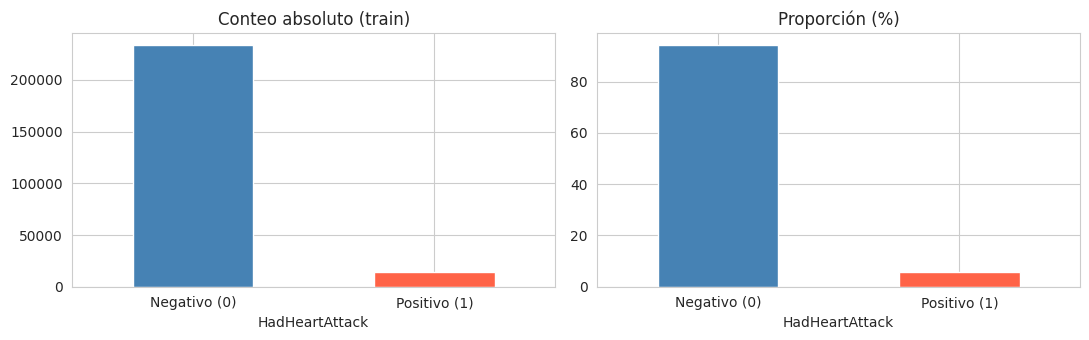

In [ ]:
# 7.1 Distribución de HadHeartAttack
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
y_train.value_counts().plot(kind='bar', ax=ax[0], color=['steelblue', 'tomato'])
ax[0].set_title('Conteo absoluto (train)')
ax[0].set_xticklabels(['Negativo (0)', 'Positivo (1)'], rotation=0)
(y_train.value_counts(normalize=True)*100).plot(kind='bar', ax=ax[1], color=['steelblue', 'tomato'])
ax[1].set_title('Proporción (%)')
ax[1].set_xticklabels(['Negativo (0)', 'Positivo (1)'], rotation=0)
plt.tight_layout(); plt.show()


**Distribución de la variable objetivo en train.** Los conteos absolutos y relativos muestran visualmente el desbalance de aproximadamente 13:1 a favor de la clase negativa. Sin rebalanceo, un clasificador trivial que siempre prediga 'no ataque' obtendría ~93 % de accuracy pero recall nulo en positivos: por eso el análisis se centra en AUC-PR, recall y g-mean en lugar de accuracy.

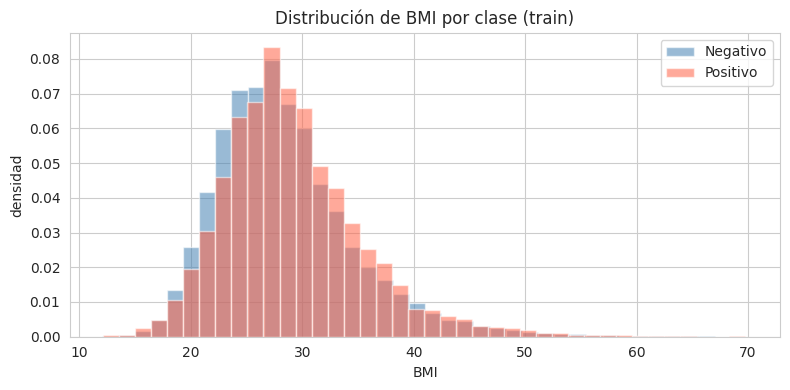

In [ ]:
# 7.2 BMI por clase
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X_train.loc[y_train == 0, 'BMI'], bins=40, alpha=0.55,
        color='steelblue', density=True, label='Negativo')
ax.hist(X_train.loc[y_train == 1, 'BMI'], bins=40, alpha=0.55,
        color='tomato', density=True, label='Positivo')
ax.set_xlabel('BMI'); ax.set_ylabel('densidad')
ax.set_title('Distribución de BMI por clase (train)')
ax.legend()
plt.tight_layout(); plt.show()


**BMI por clase.** Los histogramas normalizados permiten comparar la forma de la distribución de BMI entre ambas clases sin que el desbalance domine. El BMI medio en positivos suele ser ligeramente mayor que en negativos, pero el solapamiento es alto: por sí solo BMI no separa las clases, lo que es coherente con su importancia moderada en el modelo previo. Esta forma es la que el kernel gaussiano del KDE deberá reproducir en las sintéticas.

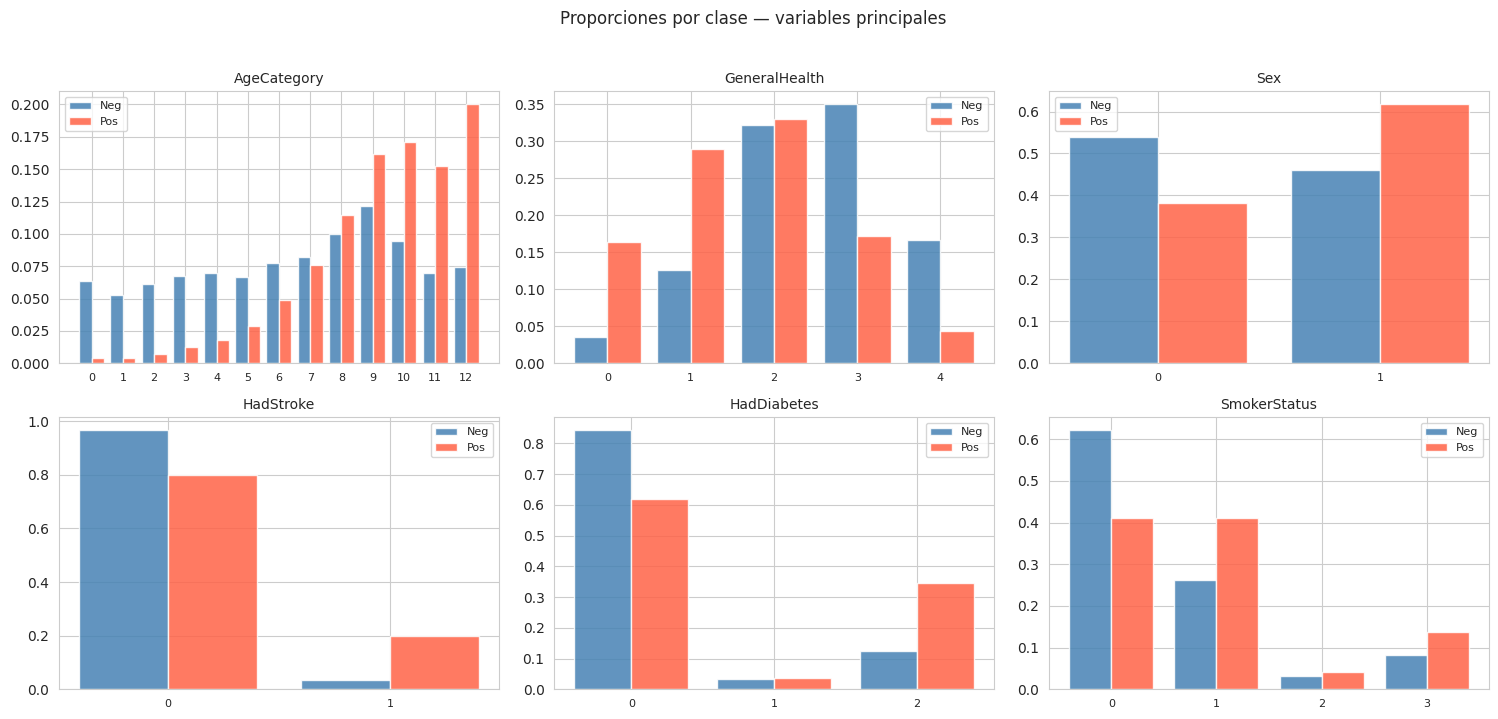

In [ ]:
# 7.3 Proporciones por clase para variables principales nominales y ordinales
PRINCIPALES_EDA = ['AgeCategory', 'GeneralHealth', 'Sex', 'HadStroke',
                   'HadDiabetes', 'SmokerStatus']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flatten(), PRINCIPALES_EDA):
    vals = sorted(X_train[col].unique())
    neg = X_train.loc[y_train == 0, col]
    pos = X_train.loc[y_train == 1, col]
    p_neg = [(neg == v).mean() for v in vals]
    p_pos = [(pos == v).mean() for v in vals]
    x = np.arange(len(vals))
    ax.bar(x - 0.2, p_neg, 0.4, label='Neg', color='steelblue', alpha=0.85)
    ax.bar(x + 0.2, p_pos, 0.4, label='Pos', color='tomato', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) if float(v) == int(v) else f'{v:.1f}' for v in vals],
                       fontsize=8)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('Proporciones por clase — variables principales', y=1.02)
plt.tight_layout(); plt.show()


**Proporciones por clase en variables clave.** Las barras evidencian que AgeCategory y GeneralHealth tienen distribuciones marcadamente distintas entre positivos y negativos (los positivos se concentran en edades altas y estados de salud peores), lo que es coherente con los Cramér's V reportados en el informe previo (HadAngina ≈ 0.43, GeneralHealth ≈ 0.21, AgeCategory ≈ 0.19). Los kernels Aitchison–Aitken y ordinal deberán preservar estos patrones al generar sintéticas.

## 8. Diagnóstico de duplicados

Al reducir de muchas variables a sólo 16, muchos perfiles se vuelven idénticos. Eso tiene dos consecuencias:

1. **Perfiles repetidos dentro de una clase** sobreponderan ciertos centros del KDE.
2. **Perfiles $X$ idénticos con $Y$ distinto** (conflictivos) imponen una cota superior al recall alcanzable: el clasificador no puede distinguirlos.

`diagnose_duplicates(X, y)` reporta ambas cosas. `deduplicate_within_classes(X, y)` se proporciona pero **sólo se aplica al train**: validation y test conservan sus duplicados (incluso conflictivos) porque reflejan la realidad poblacional.


In [ ]:
def diagnose_duplicates(X, y):
    '''Reporta duplicados exactos dentro de cada clase y perfiles X identicos
    con etiquetas distintas (conflictivos).'''
    n_total = len(X)

    # Duplicados dentro de cada clase
    dup_pos = X[y == 1].duplicated().sum()
    dup_neg = X[y == 0].duplicated().sum()

    # Perfiles X identicos con etiquetas distintas
    df_temp = X.copy(); df_temp['_y'] = y.values
    grp = df_temp.groupby(X.columns.tolist(), sort=False)['_y']
    n_classes_por_perfil = grp.nunique()
    perfiles_conflictivos = n_classes_por_perfil[n_classes_por_perfil > 1].index
    n_perfiles_conflictivos = len(perfiles_conflictivos)
    n_filas_conflictivas = df_temp.set_index(X.columns.tolist()).loc[
        perfiles_conflictivos
    ].shape[0] if n_perfiles_conflictivos else 0

    print(f"Total observaciones:                    {n_total:>10,}")
    print(f"Duplicados dentro de clase positiva:    {dup_pos:>10,}")
    print(f"Duplicados dentro de clase negativa:    {dup_neg:>10,}")
    print(f"Perfiles X conflictivos (mismo X, Y distinto): {n_perfiles_conflictivos:>10,}")
    print(f"Filas afectadas por conflicto:          {n_filas_conflictivas:>10,}  "
          f"({n_filas_conflictivas/n_total*100:.2f}% del total)")
    return {
        'dup_pos': dup_pos, 'dup_neg': dup_neg,
        'n_perfiles_conflictivos': n_perfiles_conflictivos,
        'n_filas_conflictivas': n_filas_conflictivas,
        'pct_filas_conflictivas': n_filas_conflictivas / n_total * 100,
    }


def deduplicate_within_classes(X, y):
    '''Elimina filas duplicadas dentro de cada clase. NO elimina perfiles X con
    etiquetas distintas (esos contienen informacion sobre la frontera real).'''
    df_temp = X.copy(); df_temp['_y'] = y.values
    df_d = df_temp.drop_duplicates(subset=X.columns.tolist() + ['_y'])
    return df_d.drop(columns='_y').reset_index(drop=True), \
           df_d['_y'].reset_index(drop=True)


print("=== DIAGNOSTICO DE DUPLICADOS EN TRAIN ===")
diag = diagnose_duplicates(X_train, y_train)


=== DIAGNOSTICO DE DUPLICADOS EN TRAIN ===
Total observaciones:                       248,076
Duplicados dentro de clase positiva:             4
Duplicados dentro de clase negativa:         8,540
Perfiles X conflictivos (mismo X, Y distinto):        145
Filas afectadas por conflicto:                 364  (0.15% del total)


In [ ]:
# Deduplicar SOLO el train (val y test se conservan tal cual)
X_train_d, y_train_d = deduplicate_within_classes(X_train, y_train)
print(f"\nTrain antes:    {len(X_train):,}  | positivos = {int(y_train.sum()):,}")
print(f"Train despues:  {len(X_train_d):,}  | positivos = {int(y_train_d.sum()):,}")
print(f"Reduccion: {(1 - len(X_train_d)/len(X_train))*100:.1f}%")



Train antes:    248,076  | positivos = 14,144
Train despues:  239,532  | positivos = 14,140
Reduccion: 3.4%


**Lectura de duplicados.** Los duplicados intra-clase pueden inflar artificialmente la densidad estimada por el KDE (un mismo perfil cuenta varias veces como ancla). Los **perfiles conflictivos** (mismo `X` con etiquetas distintas) son ruido irreducible: ningún modelo determinista puede separarlos. Por eso `X_train_d` se reserva **solo** para construir y optimizar el KDE; los modelos supervisados siguen entrenándose sobre `X_train` original para mantener comparabilidad metodológica con el trabajo previo.

## 9. Implementación manual del KDE mixto

### 9.1 Fundamento

Dado $\mathcal{D}^+_n = \{(b_i, \mathbf{c}_i, \mathbf{o}_i)\}_{i=1}^{n_1}$, el conjunto de positivos de entrenamiento, se estima la densidad condicional dada la clase positiva como una mezcla de productos de kernels:

$$
\hat f(b, \mathbf{c}, \mathbf{o}\mid Y=1)
= \frac{1}{n_1}\sum_{i=1}^{n_1}
   K_h(b - b_i)\;
   \prod_{j=1}^{J} A_{\lambda}(c_j, c_{ij})\;
   \prod_{\ell=1}^{L} O_{\eta}(o_\ell, o_{i\ell})
$$

con:

- **Continua** $K_h(b - b_i) = \frac{1}{h\sqrt{2\pi}}\exp\!\Big(-\tfrac{(b-b_i)^2}{2h^2}\Big)$.
- **Nominal/binaria** (Aitchison–Aitken): $A_\lambda(c, c_i)=1-\lambda$ si $c = c_i$; $\lambda/(L_j-1)$ si $c \ne c_i$, con $L_j$ el número de niveles. Suma 1 sobre el soporte.
- **Ordinal** (Wang–Van Ryzin simplificado, auto-normalizado): $O_\eta(o, o_i) = \eta^{|o - o_i|} / Z_i$, donde $Z_i = \sum_{v\in \mathcal{S}} \eta^{|v - o_i|}$.

### 9.2 Observaciones

- **No es un producto de marginales.** Es una **mezcla** de productos de kernels, cada producto **centrado en un ancla positiva real**. La marginal empírica multivariada no se construye factorizando.
- **Independencia condicional local dado el ancla:** dentro de cada componente $i$ de la mezcla, las variables son independientes (porque el kernel es producto). Pero entre componentes esa independencia no se asume.
- **Dependencia global preservada parcialmente:** como cada muestra sintética se genera desde **una misma ancla** real para todas sus dimensiones, la estructura de correlaciones presente en los positivos reales se traslada de forma aproximada a las sintéticas (la dispersión la introduce el kernel).
- **Sin afirmaciones clínicas:** el método produce muestras estadísticamente coherentes con los positivos observados, no necesariamente clínicamente plausibles. Validación clínica queda fuera del alcance.


### 9.3 Funciones del KDE mixto


In [ ]:
def get_supports(X, nominal_vars, ordinal_vars):
    '''Devuelve dict {var: array ordenado de valores observados}.'''
    sup = {}
    for col in nominal_vars + ordinal_vars:
        sup[col] = np.sort(X[col].unique())
    return sup


def sample_nominal(anchor_val, support, lambda_param, rng):
    '''Muestra una variable nominal centrada en el ancla.
    Con prob 1 - lambda devuelve el ancla; con prob lambda toma uniformemente
    una de las otras L-1 categorias.'''
    L = len(support)
    if L < 2 or lambda_param == 0.0:
        return anchor_val
    if rng.random() < (1.0 - lambda_param):
        return anchor_val
    others = [v for v in support if v != anchor_val]
    return rng.choice(others)


def sample_ordinal(anchor_val, support, eta_param, rng):
    '''Muestra una variable ordinal con peso eta^|v - anchor| sobre el soporte,
    normalizado.'''
    sup = np.asarray(support, dtype=float)
    if len(sup) < 2 or eta_param == 0.0:
        return anchor_val
    dist = np.abs(sup - float(anchor_val))
    log_w = dist * np.log(eta_param)        # log(eta^dist) = dist * log(eta)
    w = np.exp(log_w - log_w.max())
    p = w / w.sum()
    out = rng.choice(sup, p=p)
    # Mantener el dtype del soporte original (entero)
    if np.all(np.asarray(support).astype(int) == np.asarray(support)):
        out = int(round(out))
    return out


In [ ]:
def sample_mixed_kde(X_pos, n_samples, h, lambda_nom, eta_ord,
                     continuous_vars, nominal_vars, ordinal_vars,
                     supports, bmi_range, rng):
    '''Genera n_samples sinteticas desde el KDE mixto.
    Para cada muestra se elige una sola ancla positiva y de ella se generan
    TODAS las variables (no hay muestreo marginal independiente).'''
    n_anchors = len(X_pos)
    idx = rng.integers(0, n_anchors, size=n_samples)
    X_anch = X_pos.iloc[idx].reset_index(drop=True)

    out = pd.DataFrame(index=range(n_samples), columns=X_pos.columns)

    # BMI: ruido gaussiano centrado en el ancla, recortado al rango train
    if 'BMI' in continuous_vars:
        b = X_anch['BMI'].values.astype(float) + rng.standard_normal(n_samples) * h
        out['BMI'] = np.clip(b, bmi_range[0], bmi_range[1])

    # Nominales y ordinales: misma ancla para todas las dimensiones de la muestra
    for col in nominal_vars:
        anchor_vals = X_anch[col].values
        out[col] = [sample_nominal(a, supports[col], lambda_nom, rng)
                    for a in anchor_vals]

    for col in ordinal_vars:
        anchor_vals = X_anch[col].values
        out[col] = [sample_ordinal(a, supports[col], eta_ord, rng)
                    for a in anchor_vals]

    # Dtypes consistentes
    for col in X_pos.columns:
        if col == 'BMI':
            out[col] = out[col].astype(float)
        elif pd.api.types.is_integer_dtype(X_pos[col]):
            out[col] = out[col].astype(int)
        else:
            out[col] = out[col].astype(X_pos[col].dtype)

    return out[X_pos.columns]


In [ ]:
def mixed_kde_log_likelihood(X_eval, X_anchors, h, lambda_nom, eta_ord,
                              continuous_vars, nominal_vars, ordinal_vars,
                              supports):
    '''log f_hat(x*) para cada x* en X_eval bajo el KDE mixto con anclas X_anchors.

    Devuelve un array (n_eval,) con log f_hat. Usa logsumexp para estabilidad numerica.
    '''
    n_train = len(X_anchors)
    n_eval = len(X_eval)
    log_comp = np.zeros((n_eval, n_train))   # log de cada componente i para cada eval *

    # BMI
    if 'BMI' in continuous_vars:
        be = X_eval['BMI'].values.astype(float)
        ba = X_anchors['BMI'].values.astype(float)
        diff = (be[:, None] - ba[None, :]) / h
        log_comp += -0.5*np.log(2.0*np.pi) - np.log(h) - 0.5*diff**2

    # Nominales (Aitchison-Aitken)
    for col in nominal_vars:
        L = len(supports[col])
        if L < 2:
            continue
        ve = X_eval[col].values
        va = X_anchors[col].values
        match = (ve[:, None] == va[None, :])
        if lambda_nom == 0.0:
            log_comp += np.where(match, 0.0, -np.inf)
        else:
            log_match = np.log(1.0 - lambda_nom)
            log_miss  = np.log(lambda_nom / (L - 1))
            log_comp += np.where(match, log_match, log_miss)

    # Ordinales (eta^|.| auto-normalizado)
    for col in ordinal_vars:
        sup = np.asarray(supports[col], dtype=float)
        ve = X_eval[col].values.astype(float)
        va = X_anchors[col].values.astype(float)
        if eta_ord == 0.0:
            match = (ve[:, None] == va[None, :])
            log_comp += np.where(match, 0.0, -np.inf)
        else:
            log_eta = np.log(eta_ord)
            # log numerador: |ve - va| * log(eta)
            log_num = np.abs(ve[:, None] - va[None, :]) * log_eta
            # log normalizador por ancla: logsumexp_v |sup - va| * log(eta)
            dist_sup = np.abs(sup[:, None] - va[None, :])         # (L, n_train)
            log_Z = logsumexp(dist_sup * log_eta, axis=0)         # (n_train,)
            log_comp += log_num - log_Z[None, :]

    # Mezcla uniforme sobre n_train anclas
    log_f = -np.log(n_train) + logsumexp(log_comp, axis=1)
    return log_f


## 10. Optimización simple de hiperparámetros del KDE por CV

CV simple sobre los positivos del train, minimizando la NLL promedio. Grilla pequeña; sin gráficas. Se imprime el óptimo y se alerta si cae en el borde de la grilla (síntoma de necesitar extenderla).

- $h$ se parametriza como $h = c \cdot h_0$, con $h_0$ el ancho de banda de Silverman 1D para BMI sobre los positivos del train.
- $\lambda$ controla el suavizado nominal; $\eta$ el suavizado ordinal.


In [ ]:
# Anclas para el KDE: positivos del train deduplicado.
# El KDE modela la densidad CONDICIONAL a la clase positiva, por eso usamos
# el soporte observado de los positivos (no del conjunto completo): se evita
# muestrear niveles de variables ordinales/nominales que nunca aparecen en
# positivos (por ejemplo edades muy jóvenes).
X_pos_train = X_train_d[y_train_d == 1].reset_index(drop=True)
print(f"Positivos (deduplicados) en train: {len(X_pos_train):,}")

supports = get_supports(X_pos_train, NOMINAL_VARS, ORDINAL_VARS)
bmi_range_train = (X_train['BMI'].min(), X_train['BMI'].max())

# h_0 (Silverman 1D para BMI sobre positivos)
def silverman_1d(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    s = x.std(ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = (q75 - q25) / 1.34
    sigma = min(s, iqr) if iqr > 0 else s
    return 1.06 * sigma * n**(-1/5)

h0 = silverman_1d(X_pos_train['BMI'].values)
print(f"h_0 (Silverman 1D para BMI): {h0:.4f}")

Positivos (deduplicados) en train: 14,140
h_0 (Silverman 1D para BMI): 0.8774


### 10.1 ¿Por qué CV con NLL y no con AUC?

El KDE **no es un clasificador**: es un estimador no paramétrico de densidad de la clase positiva. Por eso sus hiperparámetros se eligen minimizando un criterio de bondad de ajuste de la densidad estimada, **no** una métrica de clasificación. El criterio estándar es la **log-verosimilitud negativa media** sobre datos no vistos:

$$
\hat f(x) \;=\; \frac{1}{n}\sum_{i=1}^{n} K_h(x, x_i)
$$

$$
\text{log-likelihood medio} \;=\; \frac{1}{m}\sum_{j=1}^{m} \log \hat f(x_j)
$$

$$
\mathrm{NLL} \;=\; -\frac{1}{m}\sum_{j=1}^{m} \log \hat f(x_j)
$$

$$
\mathrm{CV}(\theta) \;=\; \frac{1}{K}\sum_{k=1}^{K} \mathrm{NLL}_k(\theta), \qquad \theta=(h,\lambda,\eta)
$$

donde:

- $h$: ancho de banda del kernel gaussiano sobre BMI (suavizado de la única variable continua).
- $\lambda$: suavizado del kernel nominal Aitchison–Aitken (0 = sin suavizado discreto; 1 = uniforme).
- $\eta$: suavizado del kernel ordinal (0 = solo el nivel exacto; ↑ = mayor masa en niveles cercanos).

**¿Por qué logaritmos?** Cada $\hat f(x_j)$ es una suma de productos de muchas probabilidades pequeñas. Si las multiplicamos directamente, se produce *underflow* numérico. En escala logarítmica los productos se convierten en sumas y los términos se mantienen en rangos manejables. Para sumar densidades en escala log de forma estable usamos `logsumexp`:

$$
\log\!\left(\sum_i e^{a_i}\right) = a^* + \log\!\sum_i e^{a_i - a^*}, \quad a^* = \max_i a_i
$$

**¿Por qué búsqueda en grilla y no gradiente?** El KDE no admite optimización diferenciable directa sobre $\lambda$ (kernel discreto) y $\eta$ (basado en distancias enteras). La grilla con CV es estándar para este tipo de hiperparámetros.

In [ ]:
h_factor_grid   = [0.35, 0.50, 0.75, 1.00, 1.50, 2.00, 2.75, 3.50]
lambda_nom_grid = [0.00, 0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.25]
eta_ord_grid    = [0.00, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.45]

def optimize_kde_cv(X_pos, h0, supports, n_splits=3, max_anchors=2000, seed=RANDOM_STATE):
    '''CV simple minimizando NLL promedio sobre positivos.'''
    if len(X_pos) > max_anchors:
        X_pos = X_pos.sample(n=max_anchors, random_state=seed).reset_index(drop=True)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    results = []
    for hf in h_factor_grid:
        for lam in lambda_nom_grid:
            for eta in eta_ord_grid:
                nlls = []
                for tr_idx, vl_idx in kf.split(X_pos):
                    X_anch_cv = X_pos.iloc[tr_idx].reset_index(drop=True)
                    X_eval_cv = X_pos.iloc[vl_idx].reset_index(drop=True)
                    log_f = mixed_kde_log_likelihood(
                        X_eval_cv, X_anch_cv,
                        h=hf*h0, lambda_nom=lam, eta_ord=eta,
                        continuous_vars=CONTINUOUS_VARS,
                        nominal_vars=NOMINAL_VARS,
                        ordinal_vars=ORDINAL_VARS,
                        supports=supports,
                    )
                    if np.any(~np.isfinite(log_f)):
                        nlls.append(np.inf); break
                    nlls.append(-np.mean(log_f))
                results.append({
                    'h_factor': hf, 'lambda_nom': lam, 'eta_ord': eta,
                    'nll_mean': np.mean(nlls),
                })
    return pd.DataFrame(results).sort_values('nll_mean').reset_index(drop=True)

df_cv_kde = optimize_kde_cv(X_pos_train, h0, supports)
print("Top 5 combinaciones por NLL (menor es mejor):")
display(df_cv_kde.head(5))

Top 5 combinaciones por NLL (menor es mejor):


,h_factor,lambda_nom,eta_ord,nll_mean
0,3.50,0.15,0.30,18.822677
1,3.50,0.25,0.30,18.891617
2,2.75,0.15,0.30,18.892332
3,3.50,0.15,0.45,18.934353
4,3.50,0.10,0.30,18.935515


In [ ]:
best = df_cv_kde.iloc[0]
h_opt = float(best['h_factor']) * h0
lambda_opt = float(best['lambda_nom'])
eta_opt = float(best['eta_ord'])

print(f"\n>>> Optimo KDE:")
print(f"    h_factor = {best['h_factor']}    (h = {h_opt:.4f})")
print(f"    lambda_nom = {lambda_opt}")
print(f"    eta_ord = {eta_opt}")
print(f"    NLL = {best['nll_mean']:.4f}")

# Alertas si el optimo cae en el borde de la grilla
alerts = []
if best['h_factor']  in (min(h_factor_grid), max(h_factor_grid)):
    alerts.append(f"h_factor en borde ({best['h_factor']})")
if best['lambda_nom'] in (min(lambda_nom_grid), max(lambda_nom_grid)):
    alerts.append(f"lambda_nom en borde ({best['lambda_nom']})")
if best['eta_ord']   in (min(eta_ord_grid), max(eta_ord_grid)):
    alerts.append(f"eta_ord en borde ({best['eta_ord']})")
if alerts:
    print("\n[ALERTA] Optimo en el borde de la grilla:")
    for a in alerts:
        print(f"   - {a}")
    print("   Considerar extender la grilla en esa direccion.")
else:
    print("\nOptimo interior a la grilla.")



>>> Optimo KDE:
    h_factor = 3.5    (h = 3.0709)
    lambda_nom = 0.15
    eta_ord = 0.3
    NLL = 18.8227

[ALERTA] Optimo en el borde de la grilla:
   - h_factor en borde (3.5)
   Considerar extender la grilla en esa direccion.


**Lectura del óptimo.** El valor mostrado de `(h_factor, lambda_nom, eta_ord)` determina cuánto se suaviza la densidad en BMI, en las nominales y en las ordinales respectivamente. Un `h_factor` alto produce sintéticas más dispersas en BMI; un `lambda_nom` alto las hace casi uniformes sobre los niveles nominales; un `eta_ord` alto reparte masa entre niveles ordinales cercanos. Si el óptimo cae en el borde de la grilla, la **NLL podría seguir bajando** fuera de la grilla; en ese caso, extender la grilla en esa dirección sería el siguiente paso lógico (al costo de mayor tiempo de cómputo).

In [ ]:
# Empaquetar parametros para uso posterior
KDE_PARAMS = {
    'h': h_opt,
    'lambda_nom': lambda_opt,
    'eta_ord': eta_opt,
    'supports': supports,
    'bmi_range': bmi_range_train,
    'continuous_vars': CONTINUOUS_VARS,
    'nominal_vars': NOMINAL_VARS,
    'ordinal_vars': ORDINAL_VARS,
}


## 11. Diagnóstico básico de muestras sintéticas

Antes de meter las sintéticas a los modelos, verificamos:

1. Que sus rangos caigan dentro del rango observado.
2. Que sus categorías sean valores válidos.
3. Distribución de BMI real (positivos) vs sintética.
4. Proporciones de unas pocas variables importantes real vs sintética.


In [ ]:
def diagnose_synthetic_samples(X_pos_real, X_synth, supports, bmi_range,
                               nominal_vars, ordinal_vars, n_show=4):
    '''Diagnostico ligero: rangos, soportes y tabla corta de comparacion.'''
    print("=== DIAGNOSTICO DE SINTETICAS ===")
    # BMI: rango
    bmin, bmax = X_synth['BMI'].min(), X_synth['BMI'].max()
    print(f"BMI sint: rango = [{bmin:.2f}, {bmax:.2f}]  "
          f"(rango train = [{bmi_range[0]:.2f}, {bmi_range[1]:.2f}])  "
          f"OK={bmi_range[0] <= bmin and bmax <= bmi_range[1]}")

    # Soportes validos
    invalid = {}
    for col in nominal_vars + ordinal_vars:
        sup = set(supports[col].tolist())
        bad = ~X_synth[col].isin(sup)
        if bad.any():
            invalid[col] = int(bad.sum())
    if invalid:
        print(f"[ALERTA] Valores fuera de soporte: {invalid}")
    else:
        print("Todas las nominales/ordinales tienen valores en su soporte. OK")

    # Tabla corta de comparacion para n_show variables importantes
    cols_show = ['BMI'] + nominal_vars[:2] + ordinal_vars[:n_show-3]
    rows = []
    for col in cols_show:
        if col == 'BMI':
            rows.append({
                'var': col,
                'real_mean': X_pos_real[col].mean(),
                'synth_mean': X_synth[col].mean(),
                'real_std': X_pos_real[col].std(),
                'synth_std': X_synth[col].std(),
            })
        else:
            rows.append({
                'var': col,
                'real_mean': X_pos_real[col].mean(),
                'synth_mean': X_synth[col].mean(),
                'real_std': X_pos_real[col].std(),
                'synth_std': X_synth[col].std(),
            })
    tbl = pd.DataFrame(rows)
    print("\nComparacion de momentos (real vs sintetica):")
    print(tbl.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

    # Plot: BMI
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(X_pos_real['BMI'], bins=40, alpha=0.55, density=True,
            color='steelblue', label='Real (positivos)')
    ax.hist(X_synth['BMI'], bins=40, alpha=0.55, density=True,
            color='tomato', label='Sintetica')
    ax.set_title('BMI: positivos reales vs sinteticas')
    ax.set_xlabel('BMI'); ax.set_ylabel('densidad'); ax.legend()
    plt.tight_layout(); plt.show()

    # Plot: 3 variables importantes
    importantes = ['AgeCategory', 'GeneralHealth', 'HadStroke']
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    for ax, col in zip(axes, importantes):
        vals = sorted(set(X_pos_real[col].unique()) | set(X_synth[col].unique()))
        p_real  = [(X_pos_real[col]  == v).mean() for v in vals]
        p_synth = [(X_synth[col]     == v).mean() for v in vals]
        x = np.arange(len(vals))
        ax.bar(x - 0.2, p_real,  0.4, color='steelblue', alpha=0.85, label='Real')
        ax.bar(x + 0.2, p_synth, 0.4, color='tomato',    alpha=0.85, label='Sintetica')
        ax.set_xticks(x)
        ax.set_xticklabels([str(int(v)) if float(v) == int(v) else f'{v:.1f}'
                            for v in vals], fontsize=8)
        ax.set_title(col); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


=== DIAGNOSTICO DE SINTETICAS ===
BMI sint: rango = [12.05, 69.98]  (rango train = [12.05, 69.98])  OK=True
Todas las nominales/ordinales tienen valores en su soporte. OK

Comparacion de momentos (real vs sintetica):
        var  real_mean  synth_mean  real_std  synth_std
        BMI     29.221      29.213     6.350      6.991
  ChestScan      0.721       0.664     0.449      0.473
  HadStroke      0.200       0.294     0.400      0.456
AgeCategory      9.261       9.141     2.384      2.458


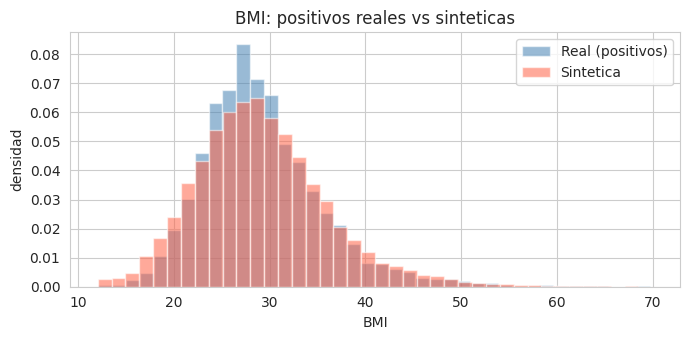

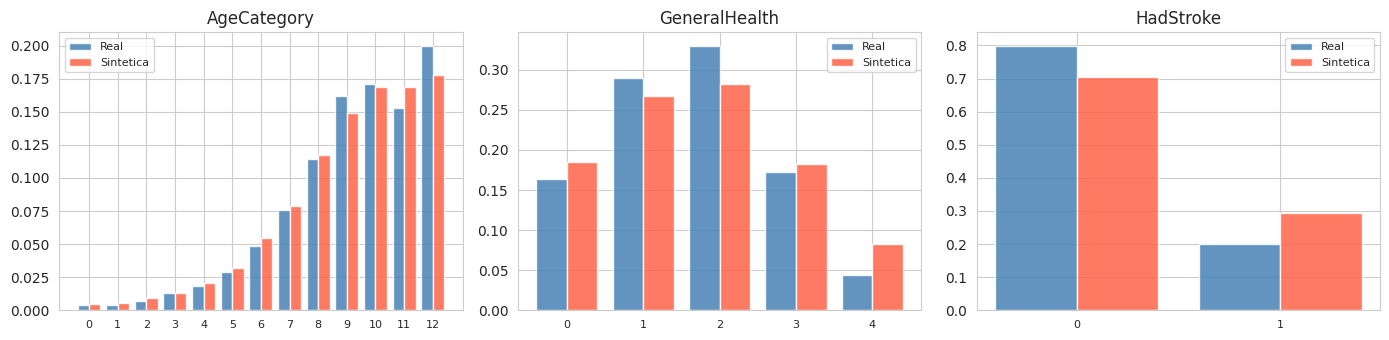

In [ ]:
# Generar un lote de sinteticas con los hiperparametros optimos y diagnosticar
rng_diag = np.random.default_rng(RANDOM_STATE)
n_diag = len(X_pos_train)
X_synth_diag = sample_mixed_kde(
    X_pos_train, n_diag,
    h=KDE_PARAMS['h'], lambda_nom=KDE_PARAMS['lambda_nom'], eta_ord=KDE_PARAMS['eta_ord'],
    continuous_vars=CONTINUOUS_VARS,
    nominal_vars=NOMINAL_VARS,
    ordinal_vars=ORDINAL_VARS,
    supports=supports,
    bmi_range=bmi_range_train,
    rng=rng_diag,
)

diagnose_synthetic_samples(
    X_pos_real=X_pos_train, X_synth=X_synth_diag,
    supports=supports, bmi_range=bmi_range_train,
    nominal_vars=NOMINAL_VARS, ordinal_vars=ORDINAL_VARS,
)


**Diagnóstico de sintéticas.** Tres criterios mínimos: (i) BMI dentro del rango observado en train (verificado por recorte explícito al sampling); (ii) las nominales/ordinales sintéticas viven en el soporte de los positivos (verificado contra `supports`); (iii) momentos comparables a los positivos reales. Esto **no** valida plausibilidad clínica — solo coherencia estadística con los positivos reales, que es lo que el KDE puede ofrecer.

## 12. Estrategias de rebalanceo

Las cinco estrategias evaluadas. Para SMOTENC, undersampling y KDE se prueban tres ratios `minoritaria:mayoritaria` = `0.25, 0.50, 1.00`.

`ratio` se interpreta como el cociente `n_minoritaria / n_mayoritaria` **después** del rebalanceo, idéntico al parámetro `sampling_strategy` de `imbalanced-learn`.


In [ ]:
def rebalance_none(X, y, **kwargs):
    '''Sin rebalanceo.'''
    return X.copy(), y.copy()


def rebalance_smotenc(X, y, ratio, random_state=RANDOM_STATE):
    '''SMOTENC con nominales y ordinales declarados como categoricos.
    BMI permanece como continua (interpolada por SMOTENC).
    SMOTE clasico NO se usa.'''
    cat_cols = NOMINAL_VARS + ORDINAL_VARS
    cat_idx = [X.columns.get_loc(c) for c in cat_cols if c in X.columns]
    sm = SMOTENC(categorical_features=cat_idx,
                 sampling_strategy=ratio,
                 random_state=random_state, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res.reset_index(drop=True), pd.Series(y_res).reset_index(drop=True)


def rebalance_undersampling(X, y, ratio, random_state=RANDOM_STATE):
    '''Random undersampling de la mayoritaria.'''
    rus = RandomUnderSampler(sampling_strategy=ratio, random_state=random_state)
    X_res, y_res = rus.fit_resample(X, y)
    return X_res.reset_index(drop=True), pd.Series(y_res).reset_index(drop=True)


def rebalance_kde(X, y, ratio, kde_params, rng):
    '''Sobremuestreo con KDE mixto hasta alcanzar el ratio deseado.'''
    X_pos = X[y == 1].reset_index(drop=True)
    X_neg = X[y == 0].reset_index(drop=True)
    n_neg = len(X_neg)
    n_pos = len(X_pos)
    n_pos_target = int(round(n_neg * ratio))
    n_gen = max(0, n_pos_target - n_pos)
    if n_gen == 0:
        return X.copy(), y.copy()

    X_synth = sample_mixed_kde(
        X_pos, n_gen,
        h=kde_params['h'],
        lambda_nom=kde_params['lambda_nom'],
        eta_ord=kde_params['eta_ord'],
        continuous_vars=kde_params['continuous_vars'],
        nominal_vars=kde_params['nominal_vars'],
        ordinal_vars=kde_params['ordinal_vars'],
        supports=kde_params['supports'],
        bmi_range=kde_params['bmi_range'],
        rng=rng,
    )
    X_combined = pd.concat([X_neg, X_pos, X_synth], ignore_index=True)
    y_combined = pd.Series([0]*len(X_neg) + [1]*(len(X_pos) + len(X_synth)))
    return X_combined[X.columns].reset_index(drop=True), y_combined.reset_index(drop=True)


## 13. Modelos y pipelines

Se conservan exactamente los modelos del notebook de clasificación previo:

- **Regresión Logística** sobre features extendidas con `BMI_log` e interacciones (sección heredada del proyecto previo). Estandarización con `StandardScaler`.
- **XGBoost** (`n_estimators=100, max_depth=6, learning_rate=0.1`).

**No se tunean.**


In [ ]:
def build_logistic_features(X):
    '''Agrega BMI_log y las 5 interacciones del proyecto previo.'''
    df_lr = X.copy()
    if 'BMI' in df_lr.columns:
        df_lr['BMI_log'] = np.log1p(df_lr['BMI'].clip(lower=0))
    if 'BMI_log' in df_lr.columns and 'AgeCategory' in df_lr.columns:
        df_lr['BMI_x_Age'] = df_lr['BMI_log'] * (df_lr['AgeCategory'] + 1)
    if 'SmokerStatus' in df_lr.columns and 'HadDiabetes' in df_lr.columns:
        df_lr['Smoker_x_Diabetes'] = df_lr['SmokerStatus'] * df_lr['HadDiabetes']
    if 'BMI_log' in df_lr.columns and 'HadDiabetes' in df_lr.columns:
        df_lr['BMI_x_Diabetes'] = df_lr['BMI_log'] * df_lr['HadDiabetes']
    if 'AgeCategory' in df_lr.columns and 'HadDiabetes' in df_lr.columns:
        df_lr['Age_x_Diabetes'] = (df_lr['AgeCategory'] + 1) * df_lr['HadDiabetes']
    if 'SmokerStatus' in df_lr.columns and 'AgeCategory' in df_lr.columns:
        df_lr['Smoker_x_Age'] = df_lr['SmokerStatus'] * (df_lr['AgeCategory'] + 1)
    return df_lr


**Nota sobre hiperparámetros.** Se reutilizan los hiperparámetros del estudio previo de clasificación (Logistic Regression con `C=0.0013`, `penalty='l2'`, `solver='lbfgs'`; GradientBoosting con `learning_rate≈0.061`, `n_estimators=121`, `max_depth=3`, `subsample≈0.504`). El objetivo es evaluar las técnicas de rebalanceo sobre modelos **ya ajustados** en el trabajo previo; **no** se espera que los resultados coincidan exactamente porque ahora se usa un subconjunto de 16 variables (vs. el conjunto completo). Sí se conserva la semilla (`random_state=42`) y la lógica de entrenamiento para mantener comparabilidad metodológica.

In [ ]:
def train_and_predict_logistic(X_tr, y_tr, X_eval, class_weight=None):
    '''Logistic Regression con BMI_log + 5 interacciones del trabajo previo.
    Hiperparámetros del trabajo previo:
        C=0.0013041036943413024, penalty='l2', solver='lbfgs', max_iter=2000.
    Cuando class_weight='balanced', sklearn calcula internamente los pesos
    a partir del y recibido.'''
    X_tr_ext = build_logistic_features(X_tr)
    X_ev_ext = build_logistic_features(X_eval)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_ext)
    X_ev_sc = scaler.transform(X_ev_ext)
    model = LogisticRegression(
        C=0.0013041036943413024,
        penalty='l2',
        solver='lbfgs',
        max_iter=2000,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_tr_sc, y_tr)
    return model.predict_proba(X_ev_sc)[:, 1], (model, scaler)


def train_and_predict_gb(X_tr, y_tr, X_eval, class_weight=None):
    '''GradientBoostingClassifier de sklearn con hiperparámetros del trabajo
    previo. El "class_weight" se implementa vía sample_weight calculado con
    el y que entra al fit.'''
    model = GradientBoostingClassifier(
        learning_rate=0.06144386194113441,
        max_depth=3,
        max_features=None,
        min_samples_leaf=5,
        min_samples_split=2,
        n_estimators=121,
        subsample=0.5035331526098588,
        random_state=RANDOM_STATE,
    )
    if class_weight == 'balanced':
        sw = compute_sample_weight(class_weight='balanced', y=y_tr)
        model.fit(X_tr, y_tr, sample_weight=sw)
    else:
        model.fit(X_tr, y_tr)
    return model.predict_proba(X_eval)[:, 1], model

## 14. Evaluación en validation

Para cada escenario × modelo:

1. Rebalancear **solo** el train.
2. Entrenar el modelo.
3. Predecir probabilidades en validation.
4. Calcular el threshold de Youden **en validation**.
5. Guardar las métricas.

El threshold no se optimiza en test.


In [ ]:
def youden_threshold(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    j = tpr - fpr
    idx = int(np.argmax(j))
    return float(thresholds[idx]), float(j[idx])


def compute_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2*prec*sens / (prec + sens) if (prec + sens) > 0 else 0.0
    acc = (tp + tn) / max(1, (tp + tn + fp + fn))
    bal = 0.5 * (sens + spec)
    g_mean = float(np.sqrt(sens * spec))     # media geométrica recall x specificity
    return {
        'threshold': threshold,
        'roc_auc': roc_auc_score(y_true, y_proba),
        'auc_pr':  average_precision_score(y_true, y_proba),
        'accuracy': acc,
        'balanced_accuracy': bal,
        'precision': prec,
        'recall': sens,
        'specificity': spec,
        'f1': f1,
        'g_mean': g_mean,
        'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
    }

In [ ]:
# Lista de escenarios (nombre, kind, ratio, model)
KDE_RATIOS = [0.25, 0.50, 1.00]
SMOTE_RATIOS = [0.25, 0.50, 1.00]
UNDER_RATIOS = [0.25, 0.50, 1.00]

def make_scenarios():
    sc = []
    for model in ['logistic', 'gb']:
        sc.append((f'none_{model}',         'none',          None, model))
        sc.append((f'class_weight_{model}', 'class_weight',  None, model))
        for r in SMOTE_RATIOS:
            sc.append((f'smotenc_{r:.2f}_{model}', 'smotenc', r, model))
        for r in UNDER_RATIOS:
            sc.append((f'undersamp_{r:.2f}_{model}', 'undersampling', r, model))
        for r in KDE_RATIOS:
            sc.append((f'kde_{r:.2f}_{model}', 'kde', r, model))
    return sc

SCENARIOS = make_scenarios()
print(f"Total escenarios (escenario x modelo): {len(SCENARIOS)}")

Total escenarios (escenario x modelo): 22


In [ ]:
def run_one_scenario(X_tr, y_tr, X_eval, y_eval,
                     rebalance_kind, ratio, model_kind,
                     kde_params, rng_seed=RANDOM_STATE):
    '''Ejecuta un escenario: rebalancea solo X_tr, entrena, predice en X_eval,
    calcula threshold de Youden en X_eval y devuelve métricas.'''
    rng = np.random.default_rng(rng_seed)
    cw = False
    if rebalance_kind == 'none':
        X_tr_b, y_tr_b = rebalance_none(X_tr, y_tr)
    elif rebalance_kind == 'class_weight':
        X_tr_b, y_tr_b = rebalance_none(X_tr, y_tr)
        cw = True
    elif rebalance_kind == 'smotenc':
        X_tr_b, y_tr_b = rebalance_smotenc(X_tr, y_tr, ratio=ratio, random_state=rng_seed)
    elif rebalance_kind == 'undersampling':
        X_tr_b, y_tr_b = rebalance_undersampling(X_tr, y_tr, ratio=ratio, random_state=rng_seed)
    elif rebalance_kind == 'kde':
        X_tr_b, y_tr_b = rebalance_kde(X_tr, y_tr, ratio=ratio, kde_params=kde_params, rng=rng)
    else:
        raise ValueError(rebalance_kind)

    if model_kind == 'logistic':
        proba, _ = train_and_predict_logistic(
            X_tr_b, y_tr_b, X_eval,
            class_weight='balanced' if cw else None,
        )
    elif model_kind == 'gb':
        # En GB el "class_weight" se traduce a sample_weight, calculado con
        # el y_tr_b que entra realmente al fit.
        proba, _ = train_and_predict_gb(
            X_tr_b, y_tr_b, X_eval,
            class_weight='balanced' if cw else None,
        )
    else:
        raise ValueError(model_kind)

    thr, _ = youden_threshold(y_eval, proba)
    m = compute_metrics(y_eval, proba, thr)
    return m, proba


def run_validation_experiments(X_train, y_train, X_val, y_val,
                               scenarios, kde_params):
    rows = []
    for name, kind, ratio, model in scenarios:
        m, _ = run_one_scenario(
            X_train, y_train, X_val, y_val,
            rebalance_kind=kind, ratio=ratio, model_kind=model,
            kde_params=kde_params,
        )
        m['scenario'] = name
        m['rebalance_kind'] = kind
        m['ratio'] = ratio
        m['model'] = model
        rows.append(m)
    return pd.DataFrame(rows)

In [ ]:
# Evaluación en validation: se entrena con X_train, y_train ORIGINALES
# (no deduplicados). La deduplicación se reserva para construir el KDE.
df_val = run_validation_experiments(
    X_train, y_train, X_val, y_val,
    SCENARIOS, KDE_PARAMS,
)

display_cols = ['scenario', 'model', 'rebalance_kind', 'ratio', 'threshold',
                'roc_auc', 'auc_pr', 'g_mean', 'balanced_accuracy',
                'precision', 'recall', 'specificity', 'f1', 'accuracy',
                'tp', 'fp', 'tn', 'fn']
df_val_sorted = df_val[display_cols].sort_values('auc_pr', ascending=False).reset_index(drop=True)
display(df_val_sorted.round(4))

,scenario,model,rebalance_kind,ratio,threshold,roc_auc,auc_pr,g_mean,balanced_accuracy,precision,recall,specificity,f1,accuracy,tp,fp,tn,fn
0,class_weight_gb,gb,class_weight,NaN,0.4784,0.8425,0.2548,0.7650,0.7663,0.1496,0.8117,0.7210,0.2526,0.7262,3827,21753,56224,888
1,none_gb,gb,none,NaN,0.0518,0.8421,0.2546,0.7655,0.7663,0.1528,0.8013,0.7314,0.2567,0.7354,3778,20944,57033,937
2,undersamp_0.25_gb,gb,undersampling,0.25,0.1841,0.8424,0.2530,0.7659,0.7668,0.1527,0.8030,0.7306,0.2566,0.7347,3786,21009,56968,929
3,none_logistic,logistic,none,NaN,0.0487,0.8415,0.2526,0.7631,0.7653,0.1454,0.8231,0.7075,0.2471,0.7140,3881,22812,55165,834
4,class_weight_logistic,logistic,class_weight,NaN,0.4549,0.8414,0.2526,0.7638,0.7654,0.1477,0.8153,0.7156,0.2501,0.7212,3844,22180,55797,871
5,undersamp_0.25_logistic,logistic,undersampling,0.25,0.1740,0.8413,0.2522,0.7632,0.7651,0.1465,0.8187,0.7115,0.2485,0.7176,3860,22494,55483,855
6,undersamp_0.50_gb,gb,undersampling,0.50,0.3263,0.8419,0.2521,0.7664,0.7671,0.1546,0.7981,0.7360,0.2590,0.7396,3763,20585,57392,952
7,undersamp_1.00_gb,gb,undersampling,1.00,0.4752,0.8417,0.2519,0.7648,0.7665,0.1483,0.8165,0.7164,0.2510,0.7221,3850,22116,55861,865
8,undersamp_0.50_logistic,logistic,undersampling,0.50,0.2833,0.8410,0.2512,0.7620,0.7648,0.1430,0.8308,0.6989,0.2440,0.7064,3917,23479,54498,798
9,undersamp_1.00_logistic,logistic,undersampling,1.00,0.4586,0.8404,0.2502,0.7631,0.7645,0.1482,0.8110,0.7181,0.2506,0.7234,3824,21985,55992,891


**Lectura del ranking en validation.** Se ordena por AUC-PR porque, con prevalencia ~7 %, es la métrica más informativa frente a accuracy o ROC-AUC. El threshold se elige por Youden **en validation** (nunca en test). Se reporta también `g_mean` = √(recall · specificity), que penaliza fuertemente cuando alguna de las dos clases se sacrifica. El siguiente paso es analizar gráficamente la trade-off entre recall y precision para cada estrategia.

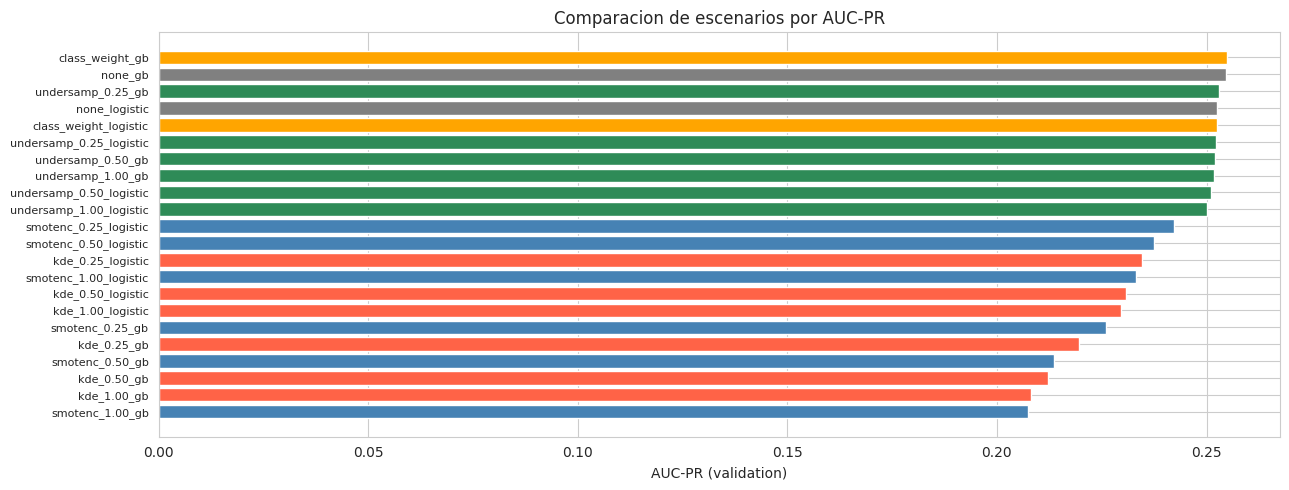

In [ ]:
# Barra de AUC-PR
fig, ax = plt.subplots(figsize=(13, 5))
order = df_val_sorted['scenario'].tolist()
colors = ['tomato' if 'kde' in s else
          'steelblue' if 'smotenc' in s else
          'seagreen' if 'undersamp' in s else
          'orange' if 'class_weight' in s else 'gray'
          for s in order]
ax.barh(np.arange(len(order)), df_val_sorted['auc_pr'].values, color=colors)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(order, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('AUC-PR (validation)')
ax.set_title('Comparacion de escenarios por AUC-PR')
plt.tight_layout(); plt.show()


**Lectura del gráfico AUC-PR.** Las barras coloreadas por tipo de rebalanceo permiten comparar de un vistazo si una estrategia domina a las demás. Diferencias pequeñas en este barchart (≤ 0.01 en AUC-PR) no son necesariamente significativas — la sección de estabilidad CV y el Wilcoxon más adelante confirman si la separación es robusta.

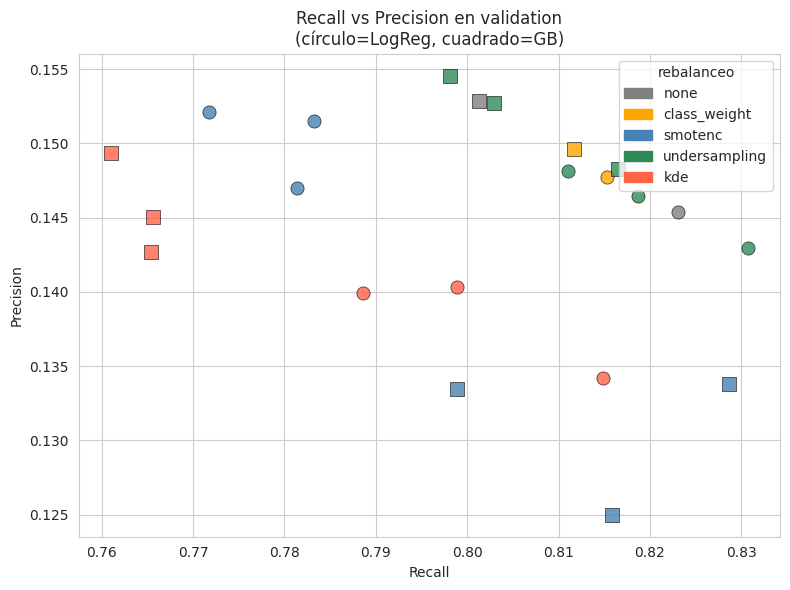

In [ ]:
# Recall vs Precision
fig, ax = plt.subplots(figsize=(8, 6))
markers = {'logistic': 'o', 'gb': 's'}
colors_map = {
    'none': 'gray', 'class_weight': 'orange',
    'smotenc': 'steelblue', 'undersampling': 'seagreen', 'kde': 'tomato',
}
for _, r in df_val.iterrows():
    ax.scatter(r['recall'], r['precision'],
               marker=markers[r['model']],
               color=colors_map[r['rebalance_kind']],
               s=90, alpha=0.8, edgecolor='k', linewidth=0.5)
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=patches, title='rebalanceo', loc='best')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Recall vs Precision en validation\n(círculo=LogReg, cuadrado=GB)')
plt.tight_layout(); plt.show()

**Lectura recall vs precision.** Los puntos en la esquina superior-derecha son los más balanceados. Los rebalanceos por oversampling (KDE, SMOTENC) y undersampling tienden a empujar recall hacia arriba a costa de precision; `class_weight` produce un efecto similar más leve. El threshold de Youden ya está aplicado, así que estos puntos reflejan la decisión clasificatoria, no solo el ranking de probabilidades.

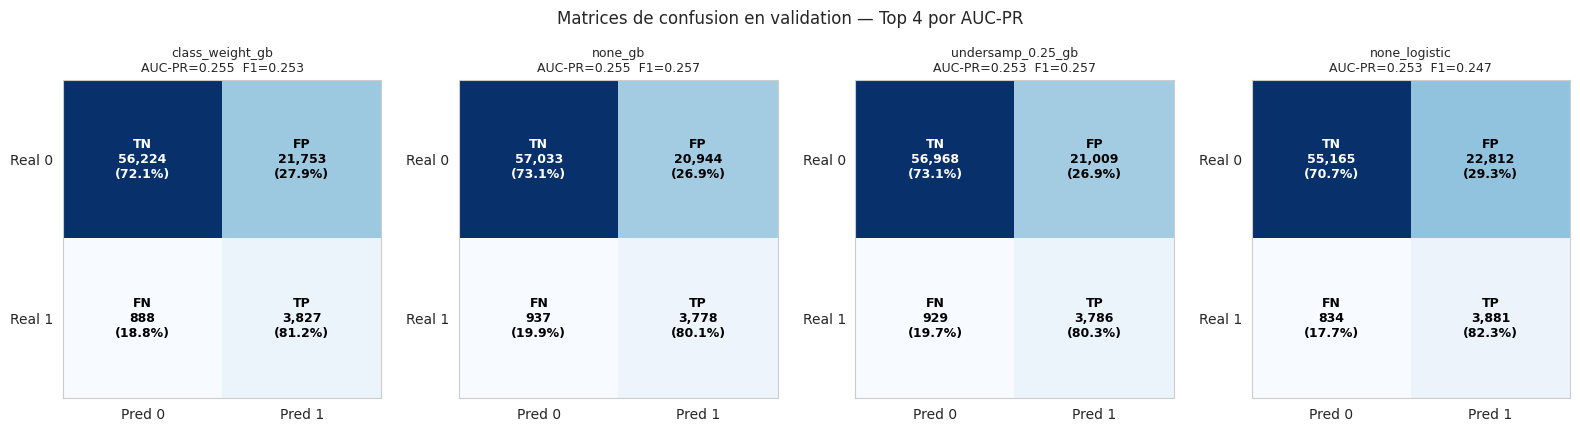

In [ ]:
# Matrices de confusion solo para los TOP-N por AUC-PR
TOP_N_CM = 4
top_scenarios = df_val_sorted.head(TOP_N_CM)
fig, axes = plt.subplots(1, TOP_N_CM, figsize=(4*TOP_N_CM, 4))
total_pos = int((y_val == 1).sum()); total_neg = int((y_val == 0).sum())

for ax, (_, r) in zip(axes, top_scenarios.iterrows()):
    tn, fp, fn, tp = int(r['tn']), int(r['fp']), int(r['fn']), int(r['tp'])
    cm = np.array([[tn, fp], [fn, tp]])
    ax.imshow(cm, cmap='Blues')
    labels = [
        [f'TN\n{tn:,}\n({tn/max(1,total_neg)*100:.1f}%)',
         f'FP\n{fp:,}\n({fp/max(1,total_neg)*100:.1f}%)'],
        [f'FN\n{fn:,}\n({fn/max(1,total_pos)*100:.1f}%)',
         f'TP\n{tp:,}\n({tp/max(1,total_pos)*100:.1f}%)'],
    ]
    for i in range(2):
        for j in range(2):
            c = 'white' if cm[i, j] > cm.max()*0.5 else 'black'
            ax.text(j, i, labels[i][j], ha='center', va='center', color=c,
                    fontsize=9, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1']); ax.set_yticklabels(['Real 0', 'Real 1'])
    ax.set_title(f"{r['scenario']}\nAUC-PR={r['auc_pr']:.3f}  F1={r['f1']:.3f}", fontsize=9)
    ax.grid(False)
plt.suptitle(f'Matrices de confusion en validation — Top {TOP_N_CM} por AUC-PR', y=1.02)
plt.tight_layout(); plt.show()


**Lectura de las matrices.** Para clasificación de eventos cardíacos un falso negativo (paciente con riesgo no identificado) tiene mayor costo clínico que un falso positivo (chequeo adicional innecesario). Las matrices muestran cómo cada Top-N distribuye ese error: estrategias con muchos TP a costa de muchos FP indican que el rebalanceo está siendo agresivo. La decisión final debe ponderar este trade-off.

## 15. Estabilidad — RepeatedStratifiedKFold (20 evaluaciones)

CV simple (no repetida) sobre `X_train_d` con `StratifiedKFold(n_splits=5)`. Para cada fold:

1. Rebalanceo solo del train del fold.
2. Entrenamiento.
3. Threshold de Youden en el validation del fold.
4. Métricas en el validation del fold.

Se reporta media, mediana, varianza y desviación estándar para AUC-PR, Recall, Precision, F1 y ROC-AUC. **No** se hacen diagramas de estabilidad.


In [ ]:
def run_cv_stability(X, y, scenarios, kde_params,
                     n_splits=5, n_repeats=4):
    '''Estabilidad con RepeatedStratifiedKFold: 5 splits x 4 repeticiones = 20
    evaluaciones por escenario. El imbalance_ratio del fold no hace falta:
    en GB el sample_weight se calcula internamente con el y del fold.'''
    rskf = RepeatedStratifiedKFold(
        n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE
    )
    rows = []
    for eval_idx, (tr_idx, vl_idx) in enumerate(rskf.split(X, y)):
        X_tr = X.iloc[tr_idx].reset_index(drop=True)
        y_tr = y.iloc[tr_idx].reset_index(drop=True)
        X_vl = X.iloc[vl_idx].reset_index(drop=True)
        y_vl = y.iloc[vl_idx].reset_index(drop=True)
        for name, kind, ratio, model in scenarios:
            m, _ = run_one_scenario(
                X_tr, y_tr, X_vl, y_vl,
                rebalance_kind=kind, ratio=ratio, model_kind=model,
                kde_params=kde_params,
                rng_seed=RANDOM_STATE + eval_idx,
            )
            m['scenario'] = name; m['model'] = model
            m['rebalance_kind'] = kind; m['ratio'] = ratio
            m['eval'] = eval_idx
            rows.append(m)
    return pd.DataFrame(rows)

In [ ]:
# Estabilidad sobre X_train, y_train ORIGINALES (no deduplicados).
# RepeatedStratifiedKFold(5,4) = 20 pares de scores por escenario.
df_cv = run_cv_stability(X_train, y_train, SCENARIOS, KDE_PARAMS,
                         n_splits=5, n_repeats=4)
n_evals = df_cv['eval'].nunique()
print(f"Evaluaciones por escenario: {n_evals}  "
      f"(esperado: 20 = 5 splits x 4 repeticiones)")
print(f"Filas totales CV: {len(df_cv)}  "
      f"(escenarios x evaluaciones = {len(SCENARIOS)} x {n_evals})")

Evaluaciones por escenario: 20  (esperado: 20 = 5 splits x 4 repeticiones)
Filas totales CV: 440  (escenarios x evaluaciones = 22 x 20)


In [ ]:
# Resumen por escenario sobre las 20 evaluaciones: media, mediana, varianza, std
METRICS_STAB = ['auc_pr', 'recall', 'precision', 'f1', 'g_mean', 'roc_auc']
g = df_cv.groupby('scenario')[METRICS_STAB]
summary = pd.concat({
    'mean':   g.mean(),
    'median': g.median(),
    'var':    g.var(ddof=1),
    'std':    g.std(ddof=1),
}, axis=1)
summary = summary.swaplevel(axis=1).sort_index(axis=1)
# Ordenar filas por AUC-PR media (más útil para comparar)
summary = summary.sort_values(('auc_pr', 'mean'), ascending=False)
display(summary.round(4))

auc_pr                           f1                  \
                           mean  median     std  var    mean  median     std   
scenario                                                                       
none_gb                  0.2642  0.2640  0.0066  0.0  0.2533  0.2530  0.0060   
class_weight_gb          0.2640  0.2631  0.0066  0.0  0.2551  0.2538  0.0083   
undersamp_0.25_gb        0.2634  0.2633  0.0067  0.0  0.2559  0.2559  0.0088   
undersamp_0.50_gb        0.2627  0.2620  0.0063  0.0  0.2547  0.2546  0.0089   
class_weight_logistic    0.2616  0.2622  0.0064  0.0  0.2545  0.2552  0.0077   
none_logistic            0.2614  0.2621  0.0064  0.0  0.2566  0.2587  0.0078   
undersamp_1.00_gb        0.2613  0.2617  0.0066  0.0  0.2573  0.2592  0.0091   
undersamp_0.25_logistic  0.2609  0.2614  0.0064  0.0  0.2547  0.2559  0.0080   
undersamp_0.50_logistic  0.2601  0.2604  0.0064  0.0  0.2540  0.2541  0.0087   
undersamp_1.00_logistic  0.2587  0.2596  0.0065  0.0  0.2535  0.2527  0.0080   
smotenc_0.25_logistic    0.2478  0.2474  0.0059  0.0  0.2493  0.2516  0.0071   
kde_0.25_logistic        0.2462  0.2454  0.0070  0.0  0.2404  0.2408  0.0042   
kde_0.50_logistic        0.2431  0.2426  0.0070  0.0  0.2357  0.2344  0.0058   
kde_1.00_logistic        0.2420  0.2416  0.0069  0.0  0.2348  0.2320  0.0071   
smotenc_0.50_logistic    0.2417  0.2404  0.0058  0.0  0.2482  0.2486  0.0071   
smotenc_1.00_logistic    0.2373  0.2359  0.0057  0.0  0.2471  0.2464  0.0067   
smotenc_0.25_gb          0.2277  0.2287  0.0068  0.0  0.2382  0.2387  0.0067   
kde_0.25_gb              0.2261  0.2255  0.0047  0.0  0.2362  0.2355  0.0061   
kde_0.50_gb              0.2196  0.2193  0.0043  0.0  0.2325  0.2309  0.0097   
kde_1.00_gb              0.2165  0.2167  0.0042  0.0  0.2365  0.2357  0.0069   
smotenc_0.50_gb          0.2157  0.2150  0.0064  0.0  0.2308  0.2314  0.0055   
smotenc_1.00_gb          0.2091  0.2085  0.0068  0.0  0.2269  0.2269  0.0060   

                                 g_mean          ... precision          \
                            var    mean  median  ...       std     var   
scenario                                         ...                     
none_gb                  0.0000  0.7690  0.7697  ...    0.0045  0.0000   
class_weight_gb          0.0001  0.7695  0.7698  ...    0.0063  0.0000   
undersamp_0.25_gb        0.0001  0.7696  0.7703  ...    0.0067  0.0000   
undersamp_0.50_gb        0.0001  0.7695  0.7701  ...    0.0068  0.0000   
class_weight_logistic    0.0001  0.7680  0.7681  ...    0.0061  0.0000   
none_logistic            0.0001  0.7684  0.7687  ...    0.0061  0.0000   
undersamp_1.00_gb        0.0001  0.7695  0.7699  ...    0.0071  0.0001   
undersamp_0.25_logistic  0.0001  0.7680  0.7682  ...    0.0063  0.0000   
undersamp_0.50_logistic  0.0001  0.7676  0.7678  ...    0.0068  0.0000   
undersamp_1.00_logistic  0.0001  0.7676  0.7681  ...    0.0063  0.0000   
smotenc_0.25_logistic    0.0001  0.7605  0.7610  ...    0.0056  0.0000   
kde_0.25_logistic        0.0000  0.7553  0.7561  ...    0.0030  0.0000   
kde_0.50_logistic        0.0000  0.7515  0.7510  ...    0.0044  0.0000   
kde_1.00_logistic        0.0001  0.7502  0.7493  ...    0.0055  0.0000   
smotenc_0.50_logistic    0.0001  0.7569  0.7578  ...    0.0057  0.0000   
smotenc_1.00_logistic    0.0000  0.7546  0.7551  ...    0.0054  0.0000   
smotenc_0.25_gb          0.0000  0.7517  0.7520  ...    0.0051  0.0000   
kde_0.25_gb              0.0000  0.7523  0.7520  ...    0.0045  0.0000   
kde_0.50_gb              0.0001  0.7466  0.7459  ...    0.0075  0.0001   
kde_1.00_gb              0.0000  0.7463  0.7454  ...    0.0052  0.0000   
smotenc_0.50_gb          0.0000  0.7426  0.7426  ...    0.0040  0.0000   
smotenc_1.00_gb          0.0000  0.7357  0.7364  ...    0.0045  0.0000   

                         recall                         roc_auc          \
                           mean  median     std     var    mean  median   
scenario               

**Lectura de la estabilidad CV.** Con 20 evaluaciones por escenario (5 splits × 4 repeticiones) cada métrica tiene una desviación estándar interpretable: si dos escenarios se diferencian en AUC-PR medio en menos de una desviación estándar conjunta, la diferencia es probablemente ruidosa. Esto es lo que el test de Wilcoxon de la siguiente sección formaliza estadísticamente. **Aumentar a 20 evaluaciones no garantiza significancia**, solo mejora la potencia exploratoria frente a 5 folds.

## 16. Wilcoxon pareado (simplificado)

Comparaciones sobre AUC-PR pareado por fold (`alternative='greater'`):

- **Mejor KDE** vs `none`.
- **Mejor KDE** vs `class_weight`.
- KDE 1:4 vs SMOTENC 1:4.
- KDE 1:2 vs SMOTENC 1:2.
- KDE 1:1 vs SMOTENC 1:1.

> **Aviso metodológico:** este análisis es **complementario**, no concluyente. Con 5 folds los datos pareados son muy pocos (`n=5`) y los folds no son completamente independientes (comparten observaciones por construcción de `StratifiedKFold`). Sirve para reforzar el ordenamiento empírico, no para sustituirlo.


**Lógica del Wilcoxon pareado.**

1. **Referencia:** se elige el escenario KDE con mayor AUC-PR medio en la CV estabilizada (no se elige con test).
2. **Comparaciones:** ese KDE se compara contra (a) `none` del mismo modelo, (b) `class_weight` del mismo modelo, (c) SMOTENC con el mismo ratio y mismo modelo, (d) undersampling con el mismo ratio y mismo modelo.
3. **Métrica de comparación:** AUC-PR por evaluación CV (20 valores pareados con la misma partición fold/repetición → comparación apareada).
4. **Test:** Wilcoxon signed-rank con `alternative='greater'`. La hipótesis es **direccional**: KDE > otro.
5. **Interpretación:** un $p$-valor pequeño indica evidencia de que el KDE supera al comparado en AUC-PR. Es evidencia **complementaria**, no prueba definitiva; conviene leerlo junto a las medias y desviaciones de la tabla de estabilidad.

In [ ]:
def wilcoxon_simple(scores_a, scores_b, name_a, name_b, alpha=0.05):
    '''Wilcoxon pareado direccional (alternative='greater'): testea si
    name_a > name_b en AUC-PR por evaluación. Devuelve un dict con W, p
    y ganador.'''
    sa = np.asarray(scores_a, dtype=float)
    sb = np.asarray(scores_b, dtype=float)
    if np.allclose(sa, sb):
        return {'W': np.nan, 'p': np.nan, 'winner': 'empate (todas las diferencias son 0)',
                'mean_a': float(sa.mean()), 'mean_b': float(sb.mean())}
    stat, p = wilcoxon(sa, sb, alternative='greater', zero_method='wilcox')
    winner = name_a if p < alpha else 'no significativo'
    return {'W': float(stat), 'p': float(p), 'winner': winner,
            'mean_a': float(sa.mean()), 'mean_b': float(sb.mean())}


# 1) Seleccionar el "mejor KDE" como el escenario KDE con mayor AUC-PR medio en CV
kde_summary = df_cv[df_cv['rebalance_kind'] == 'kde'].groupby('scenario')['auc_pr'].mean()
best_kde_name = kde_summary.idxmax()
best_kde_model = df_cv.loc[df_cv['scenario'] == best_kde_name, 'model'].iloc[0]
best_kde_ratio = df_cv.loc[df_cv['scenario'] == best_kde_name, 'ratio'].iloc[0]
print(f"Mejor KDE (por AUC-PR medio en CV): {best_kde_name}  "
      f"(modelo={best_kde_model}, ratio={best_kde_ratio})")

def scores(scen):
    return df_cv[df_cv['scenario'] == scen].sort_values('eval')['auc_pr'].values

# 2) Comparaciones: KDE vs (none, class_weight, smotenc-mismo-ratio, undersamp-mismo-ratio)
rows_wilcoxon = []

# vs baselines del mismo modelo
for baseline in [f'none_{best_kde_model}', f'class_weight_{best_kde_model}']:
    r = wilcoxon_simple(scores(best_kde_name), scores(baseline),
                        best_kde_name, baseline)
    r['comparacion'] = f'{best_kde_name}  >  {baseline}'
    rows_wilcoxon.append(r)

# vs SMOTENC y undersampling con el MISMO ratio y modelo
smotenc_same = f'smotenc_{best_kde_ratio:.2f}_{best_kde_model}'
under_same   = f'undersamp_{best_kde_ratio:.2f}_{best_kde_model}'
for opp in [smotenc_same, under_same]:
    if opp in df_cv['scenario'].unique():
        r = wilcoxon_simple(scores(best_kde_name), scores(opp),
                            best_kde_name, opp)
        r['comparacion'] = f'{best_kde_name}  >  {opp}'
        rows_wilcoxon.append(r)

df_wilcoxon = pd.DataFrame(rows_wilcoxon)[
    ['comparacion', 'mean_a', 'mean_b', 'W', 'p', 'winner']
]
display(df_wilcoxon.round(4))

Mejor KDE (por AUC-PR medio en CV): kde_0.25_logistic  (modelo=logistic, ratio=0.25)


,comparacion,mean_a,mean_b,W,p,winner
0,kde_0.25_logistic > none_logistic,0.2462,0.2614,0.0,1.0000,no significativo
1,kde_0.25_logistic > class_weight_logistic,0.2462,0.2616,0.0,1.0000,no significativo
2,kde_0.25_logistic > smotenc_0.25_logistic,0.2462,0.2478,72.0,0.8919,no significativo
3,kde_0.25_logistic > undersamp_0.25_logistic,0.2462,0.2609,0.0,1.0000,no significativo


**Lectura del Wilcoxon.** `mean_a` y `mean_b` son los AUC-PR medios en CV de los dos escenarios comparados; `W` es el estadístico signed-rank; `p` es el p-valor unilateral. Un `winner` igual al nombre del KDE indica evidencia (al nivel α=0.05) de que ese KDE supera al comparado; `no significativo` indica que la diferencia observada es compatible con ruido de muestreo a 20 evaluaciones.

## 17. Reentrenamiento con train + validation

Para la evaluación final se eligen los mejores escenarios según validation, se combinan train + validation y se reentrenan los modelos sobre esa unión. **El test se mantiene aparte y no se toca.**


In [ ]:
# Seleccionar los mejores escenarios para test:
#   - none y class_weight para cada modelo (baselines obligatorios)
#   - mejor SMOTENC, mejor undersampling y mejor KDE por modelo (según AUC-PR en validation)
def pick_best(group_kind, model):
    sub = df_val[(df_val['rebalance_kind'] == group_kind) &
                 (df_val['model'] == model)]
    if len(sub) == 0:
        return None
    return sub.sort_values('auc_pr', ascending=False).iloc[0]['scenario']

selected_scenarios = []
for model in ['logistic', 'gb']:
    selected_scenarios.append(f'none_{model}')
    selected_scenarios.append(f'class_weight_{model}')
    for kind in ['smotenc', 'undersampling', 'kde']:
        best = pick_best(kind, model)
        if best is not None:
            selected_scenarios.append(best)

df_selected = pd.DataFrame({'scenario': selected_scenarios})
display(df_selected)

,scenario
0,none_logistic
1,class_weight_logistic
2,smotenc_0.25_logistic
3,undersamp_0.25_logistic
4,kde_0.25_logistic
5,none_gb
6,class_weight_gb
7,smotenc_0.25_gb
8,undersamp_0.25_gb
9,kde_0.25_gb


**Selección de escenarios para test.** Por cada modelo (Logistic y GB) se lleva al test: los dos baselines obligatorios (`none` y `class_weight`) y el mejor de cada familia con rebalanceo (SMOTENC, undersampling, KDE) elegidos por AUC-PR **en validation**. El test nunca participa en esta selección — esa es la regla principal para evitar fuga de información.

In [ ]:
# Combinar train + validation para el reentrenamiento final.
# No deduplicamos: la deduplicación se reservó solo para construir el KDE,
# y mantener X originales conserva comparabilidad con el trabajo previo.
X_trval_all = pd.concat([X_train, X_val], ignore_index=True).reset_index(drop=True)
y_trval_all = pd.concat([y_train, y_val], ignore_index=True).reset_index(drop=True)
print(f"Train+Val: {len(X_trval_all):,}  | positivos = {int(y_trval_all.sum()):,}  "
      f"({y_trval_all.mean()*100:.2f}%)")

Train+Val: 330,768  | positivos = 18,859  (5.70%)


## 18. Evaluación final en test

- Rebalanceo aplicado **únicamente** al conjunto train+validation.
- Se reentrena cada modelo.
- Se predicen probabilidades en test **una sola vez**.
- El threshold de Youden **se toma de la validation**, no se recalcula en test.


In [ ]:
# Mapa escenario -> (kind, ratio, model)
sc_meta = {name: (kind, ratio, model) for (name, kind, ratio, model) in SCENARIOS}
# Threshold congelado por escenario, tomado de validation (NUNCA se reelige con test)
thr_from_val = {row['scenario']: row['threshold'] for _, row in df_val.iterrows()}

test_rows = []
for name in selected_scenarios:
    kind, ratio, model = sc_meta[name]
    rng = np.random.default_rng(RANDOM_STATE)

    cw = (kind == 'class_weight')
    if kind == 'none' or cw:
        X_tr_b, y_tr_b = rebalance_none(X_trval_all, y_trval_all)
    elif kind == 'smotenc':
        X_tr_b, y_tr_b = rebalance_smotenc(X_trval_all, y_trval_all, ratio=ratio)
    elif kind == 'undersampling':
        X_tr_b, y_tr_b = rebalance_undersampling(X_trval_all, y_trval_all, ratio=ratio)
    elif kind == 'kde':
        X_tr_b, y_tr_b = rebalance_kde(X_trval_all, y_trval_all, ratio=ratio,
                                       kde_params=KDE_PARAMS, rng=rng)
    else:
        raise ValueError(kind)

    if model == 'logistic':
        proba_test, _ = train_and_predict_logistic(
            X_tr_b, y_tr_b, X_test,
            class_weight='balanced' if cw else None,
        )
    else:  # 'gb'
        proba_test, _ = train_and_predict_gb(
            X_tr_b, y_tr_b, X_test,
            class_weight='balanced' if cw else None,
        )

    thr = thr_from_val[name]                # threshold CONGELADO desde validation
    m = compute_metrics(y_test, proba_test, thr)
    m['scenario'] = name
    m['model'] = model
    m['rebalance_kind'] = kind
    m['ratio'] = ratio
    test_rows.append(m)

df_test_res = pd.DataFrame(test_rows)

In [ ]:
# Tabla final en test, ordenada por AUC-PR
show_cols = ['scenario', 'model', 'rebalance_kind', 'ratio', 'threshold',
             'roc_auc', 'auc_pr', 'g_mean', 'balanced_accuracy',
             'precision', 'recall', 'specificity', 'f1', 'accuracy',
             'tp', 'fp', 'tn', 'fn']
df_test_view = df_test_res[show_cols].sort_values('auc_pr', ascending=False).reset_index(drop=True)
display(df_test_view.round(4))

,scenario,model,rebalance_kind,ratio,threshold,roc_auc,auc_pr,g_mean,balanced_accuracy,precision,recall,specificity,f1,accuracy,tp,fp,tn,fn
0,class_weight_gb,gb,class_weight,NaN,0.4784,0.8422,0.2608,0.7631,0.7644,0.1487,0.8087,0.7201,0.2512,0.7251,3813,21826,56151,902
1,none_gb,gb,none,NaN,0.0518,0.8418,0.2608,0.7633,0.7641,0.1512,0.7996,0.7286,0.2543,0.7326,3770,21163,56814,945
2,undersamp_0.25_gb,gb,undersampling,0.25,0.1841,0.8421,0.2604,0.7638,0.7648,0.1509,0.8028,0.7268,0.2540,0.7311,3785,21305,56672,930
3,class_weight_logistic,logistic,class_weight,NaN,0.4549,0.8395,0.2590,0.7625,0.7641,0.1471,0.8136,0.7147,0.2491,0.7203,3836,22246,55731,879
4,none_logistic,logistic,none,NaN,0.0487,0.8395,0.2588,0.7627,0.7649,0.1451,0.8231,0.7067,0.2467,0.7133,3881,22871,55106,834
5,undersamp_0.25_logistic,logistic,undersampling,0.25,0.1740,0.8395,0.2584,0.7618,0.7637,0.1458,0.8168,0.7106,0.2474,0.7167,3851,22565,55412,864
6,smotenc_0.25_logistic,logistic,smotenc,0.25,0.1943,0.8317,0.2475,0.7550,0.7553,0.1505,0.7750,0.7356,0.2521,0.7378,3654,20619,57358,1061
7,kde_0.25_logistic,logistic,kde,0.25,0.1400,0.8270,0.2424,0.7483,0.7497,0.1396,0.7960,0.7035,0.2376,0.7087,3753,23124,54853,962
8,smotenc_0.25_gb,gb,smotenc,0.25,0.1466,0.8257,0.2319,0.7442,0.7480,0.1320,0.8235,0.6725,0.2275,0.6811,3883,25535,52442,832
9,kde_0.25_gb,gb,kde,0.25,0.1507,0.8250,0.2217,0.7447,0.7447,0.1479,0.7512,0.7382,0.2471,0.7390,3542,20411,57566,1173


**Lectura del test final.** Este es el único momento del notebook en que se usa el conjunto de test, y se hace con threshold **congelado desde validation** para evitar fuga. La comparación entre cada escenario y los baselines (`none`, `class_weight`) responde la pregunta del trabajo: ¿aporta el rebalanceo a la clasificación de ataques cardíacos? El AUC-PR y g-mean son los indicadores principales; recall y precision detallan el trade-off clínico.

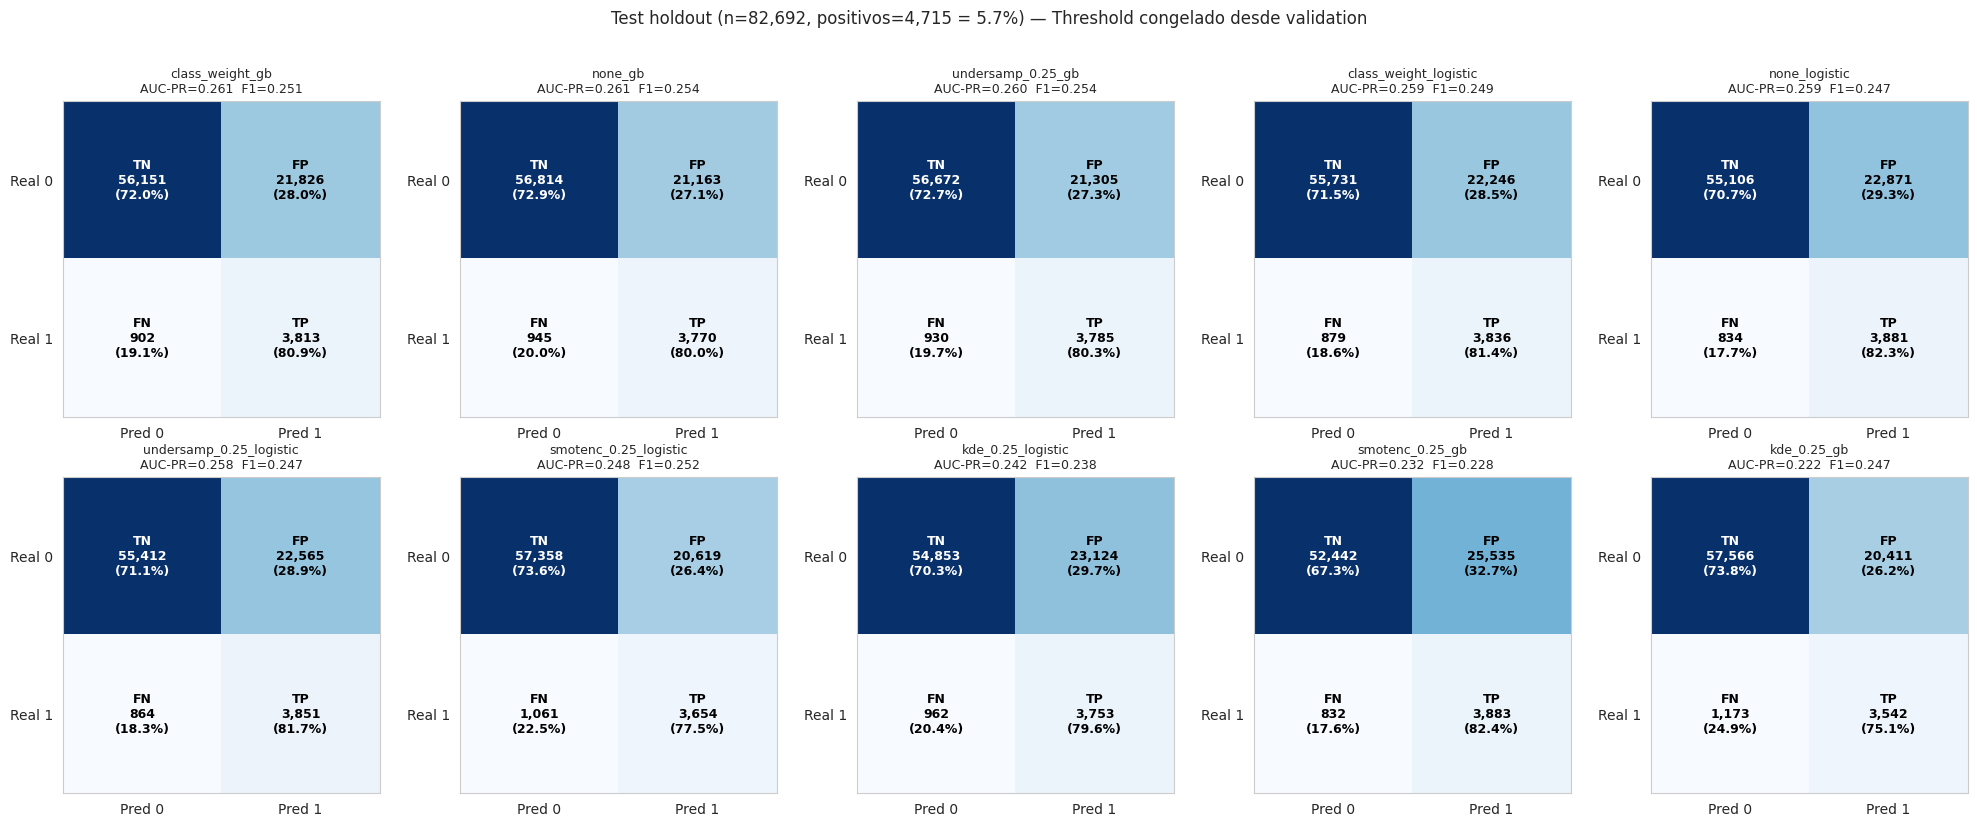

In [ ]:
# Matrices de confusion finales
n_show = len(df_test_view)
cols = min(n_show, 5)
rows = int(np.ceil(n_show / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = np.atleast_2d(axes).flatten()
total_pos = int((y_test == 1).sum()); total_neg = int((y_test == 0).sum())
for ax, (_, r) in zip(axes, df_test_view.iterrows()):
    tn, fp, fn, tp = int(r['tn']), int(r['fp']), int(r['fn']), int(r['tp'])
    cm = np.array([[tn, fp], [fn, tp]])
    ax.imshow(cm, cmap='Blues')
    labels = [
        [f'TN\n{tn:,}\n({tn/max(1,total_neg)*100:.1f}%)',
         f'FP\n{fp:,}\n({fp/max(1,total_neg)*100:.1f}%)'],
        [f'FN\n{fn:,}\n({fn/max(1,total_pos)*100:.1f}%)',
         f'TP\n{tp:,}\n({tp/max(1,total_pos)*100:.1f}%)'],
    ]
    for i in range(2):
        for j in range(2):
            c = 'white' if cm[i, j] > cm.max()*0.5 else 'black'
            ax.text(j, i, labels[i][j], ha='center', va='center', color=c,
                    fontsize=9, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1']); ax.set_yticklabels(['Real 0', 'Real 1'])
    ax.set_title(f"{r['scenario']}\nAUC-PR={r['auc_pr']:.3f}  F1={r['f1']:.3f}", fontsize=9)
    ax.grid(False)
# Ocultar ejes sobrantes
for k in range(len(df_test_view), len(axes)):
    axes[k].axis('off')
plt.suptitle(f'Test holdout (n={len(y_test):,}, positivos={total_pos:,} = '
             f'{total_pos/len(y_test)*100:.1f}%) — Threshold congelado desde validation',
             y=1.02)
plt.tight_layout(); plt.show()


**Lectura de las matrices finales.** TP y FN son las celdas críticas en salud cardiovascular. Un escenario con muchos TP a costa de FP elevados indica un modelo sensible pero poco específico (útil como screening, no como diagnóstico definitivo). El umbral de Youden busca un balance, pero en aplicación clínica real conviene revisar también la calibración de probabilidades — fuera del alcance de este trabajo.

In [ ]:
print(f"Tiempo total de ejecución: {(time.time() - t0_total)/60:.2f} minutos")

Tiempo total de ejecución: 275.05 minutos
